<a href="https://colab.research.google.com/github/hatchey/NHL-Big-Data-Cup-2026/blob/main/Big_Data_Cup_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sportypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 7.4 MB/s eta 0:00:00


In [2]:
# Core Python
import math
import os
import re
import warnings

# Data Science
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.ndimage import gaussian_filter

# Visualization
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Patch, FancyBboxPatch
import networkx as nx

# Hockey-specific / Notebook utilities
from sportypy.surfaces.hockey import NHLRink
from IPython.display import HTML
from google.colab import files

np.random.seed(42)

In [3]:
BASE_URL = "https://github.com/bigdatacup/Big-Data-Cup-2026/releases/download/Data"

games = [
    "2025-10-11.Team.A.@.Team.D",
    "2025-10-17.Team.F.@.Team.L",
    "2025-10-24.Team.B.@.Team.A",
    "2025-10-24.Team.E.@.Team.D",
    "2025-10-28.Team.C.@.Team.A",
    "2025-10-29.Team.G.@.Team.L",
    "2025-11-02.Team.D.@.Team.A",
    "2025-11-16.Team.H.@.Team.K",
    "2025-11-19.Team.I.@.Team.K",
    "2025-11-28.Team.J.@.Team.K"
]

tracking_df = pd.DataFrame()
events_df = pd.DataFrame()
shifts_df = pd.DataFrame()

for game in games:
    # Read in files from Big Data Bowl github
    df_p1 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P1.csv")
    df_p2 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P2.csv")
    df_p3 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P3.csv")

    # Optional overtime period
    df_ot = None
    try:
        df_ot = pd.read_csv(f"{BASE_URL}/{game}.Tracking_POT.csv")
    except Exception:
        pass

    if df_ot is not None:
        df = pd.concat([df_p1, df_p2, df_p3, df_ot], ignore_index=True)
    else:
        df = pd.concat([df_p1, df_p2, df_p3], ignore_index=True)

    tracking_df = pd.concat([tracking_df, df], ignore_index=True)

    # Events
    events_game_df = pd.read_csv(f"{BASE_URL}/{game}.Events.csv")
    events_df = pd.concat([events_df, events_game_df], ignore_index=True)

    # Shifts
    shifts_game_df = pd.read_csv(f"{BASE_URL}/{game}.Shifts.csv")
    shifts_df = pd.concat([shifts_df, shifts_game_df], ignore_index=True)

# Rink orientations
rink_orientation_df = pd.read_csv(f"{BASE_URL}/camera_orientations.csv")

/tmp/ipykernel_343/493953868.py:22: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p1 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P1.csv")
/tmp/ipykernel_343/493953868.py:23: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p2 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P2.csv")
/tmp/ipykernel_343/493953868.py:24: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p3 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P3.csv")
/tmp/ipykernel_343/493953868.py:22: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p1 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P1.csv")
/tmp/ipykernel_343/493953868.py:23: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p2 = pd.read_csv(f"{BASE_URL}/{game}.Tracking_P2.csv")
/tmp/ipykernel_

In [4]:
tracking_df.loc[
    tracking_df['Game Clock'].apply(lambda x: isinstance(x, (float, int))),
    'Game Clock'
].head(20)

,Game Clock
643112,NaN
643113,NaN
643114,NaN
643115,NaN
643116,NaN
643117,NaN
643118,NaN
643119,NaN
643120,NaN
643121,NaN


In [5]:
tracking_df['GameId'] = tracking_df['Image Id'].str.split('_', n = 1, expand=False).str[0]
period_map = {
    '1' : 1,
    '2' : 2,
    '3' : 3,
    'OT' : 4
}

tracking_df['Period'] = tracking_df['Period'].astype(str).map(period_map)
tracking_df['Time'] = (s := tracking_df["Game Clock"].str.split(":")).str[0].astype(float) + (s.str[1].astype(float) / 60)
tracking_df['Team'] = tracking_df['Team'].fillna('Puck')
tracking_df['Player Jersey Number'] = tracking_df['Player Jersey Number'].fillna('Puck')
tracking_df = tracking_df[(tracking_df['Rink Location X (Feet)'] != '') | (tracking_df['Rink Location Y (Feet)']  != '') | (tracking_df['Rink Location Z (Feet)']  != '')]

tracking_df_avg = tracking_df.groupby(['GameId', 'Period', 'Time', 'Team', 'Player Jersey Number']).agg(
    RinkLocationX = ('Rink Location X (Feet)', 'mean'),
    RinkLocationY = ('Rink Location Y (Feet)', 'mean'),
    RinkLocationZ = ('Rink Location Z (Feet)', 'mean'),
    GoalScored = ('Goal Score', 'first')
).reset_index().rename(columns = {'Team' : 'Home'}).sort_values(by=['GameId', 'Period', 'Time'],ascending=[True, True, False], axis = 0)

In [6]:
tracking_df_avg['Date'] = pd.to_datetime(tracking_df_avg['GameId'].str[0:10], format = 'mixed').dt.normalize()
tracking_df_avg['Home_Team'] = tracking_df_avg['GameId'].str[20:26].str.strip()
tracking_df_avg['Away_Team'] = tracking_df_avg['GameId'].str[11:17].str.strip()
tracking_df_avg['Team'] = np.where(tracking_df_avg['Home'] == 'Home',
                                   tracking_df_avg['Home_Team'],
                                   np.where(tracking_df_avg['Home'] == 'Away',
                                            tracking_df_avg['Away_Team'],
                                            'Puck'))

events_df['Time'] = (s := events_df['Clock'].str.split(":")).str[0].astype(float) + (s.str[1].astype(float) / 60)
events_df['Date'] = pd.to_datetime(events_df['Date'], format = 'mixed').dt.normalize()
shifts_df['Shift_Start_Time'] = (s := shifts_df['start_clock'].str.split(':')).str[0].astype(float) + (s.str[1].astype(float) / 60)
shifts_df['Shift_End_Time'] = (s:= shifts_df['end_clock'].str.split(':')).str[0].astype(float) + (s.str[1].astype(float) / 60)
shifts_df['Home_Team'] = shifts_df['Home_Team'].str.strip()
shifts_df['Away_Team'] = shifts_df['Away_Team'].str.strip()
shifts_df['Team'] = shifts_df['Team'].str.strip()
shifts_df['period'] = shifts_df['period'].astype('float')
shifts_df['Date'] = pd.to_datetime(shifts_df['Date'], format='mixed').dt.normalize()

tracking_events_df = pd.merge(
    tracking_df_avg,
    events_df,
    how = 'outer',
    on = ['Date', 'Home_Team', 'Away_Team', 'Period', 'Time'],
    suffixes = ('_Tracking', '_Events'))

tracking_events_df['has_tracking'] = tracking_events_df['RinkLocationX'].notna()

tracking_events_df['Date'] = tracking_events_df['Date'].dt.strftime('%Y-%m-%d')

tracking_events_df['GameId'] = np.where(tracking_events_df['GameId'].isna(),
                                        tracking_events_df['Date'].astype(str) + " " +
                                        tracking_events_df['Away_Team'] + " @ " +
                                        tracking_events_df['Home_Team'],
                                        tracking_events_df['GameId'])

full_df = pd.merge(
    tracking_events_df,
    rink_orientation_df,
    how = 'left',
    left_on = ['GameId'],
    right_on = ['Game']
)

full_df['Home'] = full_df['Home'].fillna('Puck')
full_df['Player Jersey Number'] = full_df['Player Jersey Number'].fillna('Puck')
full_df = full_df.sort_values(by = ['GameId', 'Date', 'Period', 'Time', 'Team_Tracking', 'Player Jersey Number'],
                              ascending = [True, True, True, False, True, True])
full_df['GoalieTeamOnRightSideOfRink'] = np.where((full_df['GoalieTeamOnRightSideOfRink1stPeriod'] == 'Home') & ((full_df['Period'] == 1) | (full_df['Period'] == 3)), full_df['Home_Team'], full_df['Away_Team'])
full_df['Possession'] = np.where((full_df['Event'] == 'Puck Recovery') | (full_df['Event'] == 'Takeaway'), full_df['Team_Events'], None)
full_df[['Home_Team_Skaters', 'Away_Team_Skaters', 'Home_Team_Goals', 'Away_Team_Goals', 'Possession']] = (
    full_df[['Home_Team_Skaters', 'Away_Team_Skaters',
              'Home_Team_Goals', 'Away_Team_Goals', 'Possession']].ffill()
)
full_df['PlayDirection'] = np.where(full_df['Possession'] == full_df['GoalieTeamOnRightSideOfRink'], 'Left', 'Right')
full_df['RinkLocationX'] = np.where(full_df['PlayDirection'] == 'Right', full_df['RinkLocationX'], full_df['RinkLocationX'] * -1)
full_df['RinkLocationY'] = np.where(full_df['PlayDirection'] == 'Right', full_df['RinkLocationY'], full_df['RinkLocationY'] * -1)

full_df['PowerPlay'] = np.where(((full_df['Home_Team_Skaters'] == 4) & (full_df['Away_Team_Skaters'] == 5)) | ((full_df['Home_Team_Skaters'] == 5) & (full_df['Away_Team_Skaters'] == 4)), True, False)
full_df['PowerPlayTeam'] = np.where(
    (full_df['Home_Team_Skaters'] == 5) & (full_df['Away_Team_Skaters'] == 4),
    full_df['Home_Team'],
    np.where(
        (full_df['Home_Team_Skaters'] == 4) & (full_df['Away_Team_Skaters'] == 5),
        full_df['Away_Team'],
        None
    )
)

power_play_df = full_df[full_df['PowerPlay'] == True].copy()

power_play_df['is_ozone'] = (
    (power_play_df['Team_Tracking'] == 'Puck') &
    (power_play_df['RinkLocationX'] > 30)
)

power_play_df['is_ozone'] = power_play_df.groupby(
    ['GameId', 'Date', 'Period', 'Time', 'Home_Team', 'Away_Team']
)['is_ozone'].transform('any')

power_play_df['PKPossession'] = (
    ((power_play_df['Event'] == 'Puck Recovery') |
     (power_play_df['Event'] == 'Takeaway')) &
    (power_play_df['Team_Events'] != power_play_df['PowerPlayTeam'])
)

power_play_df['RinkLocationX'] = np.where(
    power_play_df['PKPossession'],
    power_play_df['RinkLocationX'] * -1,
    power_play_df['RinkLocationX']
)
power_play_df['RinkLocationY'] = np.where(
    power_play_df['PKPossession'],
    power_play_df['RinkLocationY'] * -1,
    power_play_df['RinkLocationY']
)
power_play_df['is_ozone'] = np.where(
    power_play_df['PKPossession'], True, power_play_df['is_ozone']
)

event_priority_map = {
    'Puck Recovery': 1, 'Zone Entry': 1, 'Takeaway': 1,
    'Play': 2,
    'Shot': 3, 'Faceoff Win': 3, 'Incomplete Play': 3, 'Goal': 3
}

power_play_df['EventPriority'] = power_play_df['Event'].map(event_priority_map)

print(f"Power play rows: {power_play_df.shape[0]}")
print(f"Power play events: {power_play_df['Event'].value_counts()}")

# Deduplicate
events_only = power_play_df[power_play_df['Event'].notna()].copy()

events_only = (
    events_only
    .sort_values(['GameId', 'Period', 'Time', 'EventPriority'],
                 ascending=[True, True, False, True])
    .drop_duplicates(subset=['GameId', 'Period', 'Time', 'Event'])
    .reset_index(drop=True)
)

events_only['is_pp_team'] = events_only['PowerPlayTeam'] == events_only['Team_Events']
events_only['in_ozone'] = events_only['is_ozone'] == True

# Mark sequence starts
events_only['sequence_start'] = (
    (events_only['Event'].isin(['Puck Recovery', 'Takeaway']) &
     events_only['in_ozone'] &
     events_only['is_pp_team']) |
    (events_only['Event'] == 'Zone Entry') &
     events_only['is_pp_team']
)

# Assign sequence ids
events_only['SequenceId'] = (
    events_only
    .groupby(['GameId', 'Period'])['sequence_start']
    .cumsum()
)

events_only['SequenceId'] = np.where(
    events_only['SequenceId'] == 0, np.nan, events_only['SequenceId']
)

events_only['SequenceId'] = np.where(
    events_only['SequenceId'].notna(),
    events_only['GameId'].astype(str) + '_' +
    events_only['Period'].astype(str) + '_' +
    events_only['SequenceId'].astype(str),
    np.nan
)


# Mark sequence ends within sequences
events_only = events_only.sort_values(
    ['GameId', 'Period', 'SequenceId', 'Time']
).reset_index(drop=True)

# A Puck Recovery ends the sequence if it belongs to a DIFFERENT sequence
# i.e. it is a sequence_start for the NEXT sequence
events_only['next_is_start'] = (
    events_only
    .groupby(['GameId', 'Period'])['sequence_start']
    .shift(-1)
    .fillna(False)
)

events_only['sequence_end'] = (
    events_only['Event'].isin([
        'Shot', 'Goal', 'Incomplete Play', 'Faceoff Win', 'Dump In/Out'
    ]) |
    # Puck recovery/takeaway outside ozone ends sequence
    (events_only['Event'].isin(['Puck Recovery', 'Takeaway']) &
     ~events_only['in_ozone']) |
    # Opponent puck recovery/takeaway ends sequence
    (events_only['Event'].isin(['Puck Recovery', 'Takeaway']) &
     ~events_only['is_pp_team']) |
    # Next event starts a new sequence
    events_only['next_is_start']
)


# Truncate after first event
events_only['cumulative_end'] = (
    events_only
    .groupby(['GameId', 'Period', 'SequenceId'])['sequence_end']
    .cumsum()
)

events_only = events_only[
    events_only['SequenceId'].notna() &
    (
        (events_only['cumulative_end'] == 0) |
        (events_only['sequence_end'] == True)
    )
].copy()

print("End events after truncation:")
print(events_only.groupby('SequenceId').last()['Event'].value_counts())

print("\nSequence length distribution:")
print(events_only.groupby('SequenceId').size().describe())


# Count passes and filter
events_only['in_ozone_pass'] = (
    (events_only['Event'] == 'Play') &
    (events_only['is_ozone'] == True)
)

sequence_stats = (
    events_only
    .groupby(['GameId', 'Period', 'Home_Team', 'Away_Team', 'SequenceId'])
    .agg(
        total_passes=('Event', lambda x: (x == 'Play').sum()),
        ozone_passes=('in_ozone_pass', 'sum'),
        has_proper_end=('sequence_end', lambda x:
            events_only.loc[x.index, 'Event'].isin([
                'Shot', 'Goal', 'Incomplete Play',
                'Faceoff Win', 'Dump In/Out', 'Takeaway'
            ]).any()),
        sequence_length=('Event', 'count'),
        team=('PowerPlayTeam', 'first')
    )
    .reset_index()
)

valid_sequences = sequence_stats[
    (sequence_stats['total_passes'] >= 2) &
    (sequence_stats['ozone_passes'] >= 1) &
    sequence_stats['has_proper_end']
]['SequenceId'].unique()

print(f"Valid sequences: {len(valid_sequences)}")


# Join tracking data back in
puck_tracking_df = power_play_df[
    power_play_df['Team_Tracking'] == 'Puck'
].copy()

sequence_id_map = events_only[
    ['GameId', 'Period', 'Time', 'SequenceId']
].dropna(subset=['SequenceId'])

puck_tracking_df = pd.merge(
    puck_tracking_df,
    sequence_id_map,
    on=['GameId', 'Period', 'Time'],
    how='left'
)

puck_tracking_df = puck_tracking_df.sort_values(['GameId', 'Period', 'Time'])
puck_tracking_df['SequenceId'] = (
    puck_tracking_df
    .groupby(['GameId', 'Period'])['SequenceId']
    .ffill()
)

puck_tracking_df['SequenceId'] = np.where(
    puck_tracking_df['is_ozone'] == True,
    puck_tracking_df['SequenceId'],
    np.nan
)

puck_tracking_df = puck_tracking_df[
    puck_tracking_df['SequenceId'].isin(valid_sequences)
].copy()


# Combine event and tracking data
combined_df = pd.concat([
    events_only[events_only['SequenceId'].isin(valid_sequences)],
    puck_tracking_df
]).drop_duplicates(
    subset=['GameId', 'Period', 'Time', 'SequenceId']
).sort_values(['SequenceId', 'Time']).reset_index(drop=True)

combined_df = combined_df[combined_df['RinkLocationX'].notna()].copy()
combined_df = combined_df[combined_df['is_ozone'] == True].copy()

combined_df['RinkLocationX'] = combined_df['RinkLocationX'] - 25
combined_df['RinkLocationY'] = combined_df['RinkLocationY'] + 42.5
combined_df['Team_Events'] = combined_df['PowerPlayTeam']

ppp_ozone_df = combined_df.copy()

print(f"\nFinal sequences: {ppp_ozone_df['SequenceId'].nunique()}")
print(f"Final rows: {ppp_ozone_df.shape[0]}")
print(f"Mean rows per sequence: {ppp_ozone_df.groupby('SequenceId').size().mean():.1f}")
print(f"\nSequence length distribution:")
print(ppp_ozone_df.groupby('SequenceId').size().describe())
print(f"\nSequences per team:")
print(ppp_ozone_df.groupby('PowerPlayTeam')['SequenceId'].nunique().sort_values(ascending=False))

# Clean Up

# Remove Team I
ppp_ozone_df = ppp_ozone_df[ppp_ozone_df['PowerPlayTeam'] != 'Team I'].copy()

# Align Team_Events with PowerPlayTeam
ppp_ozone_df['Team_Events'] = ppp_ozone_df['PowerPlayTeam']

# Remove single row sequences
short_seqs = ppp_ozone_df.groupby('SequenceId').size()
valid_seqs = short_seqs[short_seqs >= 2].index
ppp_ozone_df = ppp_ozone_df[ppp_ozone_df['SequenceId'].isin(valid_seqs)].copy()

print(f"Final sequences: {ppp_ozone_df['SequenceId'].nunique()}")
print(f"Final rows: {ppp_ozone_df.shape[0]}")
print(f"Mean rows per sequence: {ppp_ozone_df.groupby('SequenceId').size().mean():.1f}")
print(f"\nSequence length distribution:")
print(ppp_ozone_df.groupby('SequenceId').size().describe())
print(f"\nSequences per team:")
print(ppp_ozone_df.groupby('PowerPlayTeam')['SequenceId'].nunique().sort_values(ascending=False))
print(f"\nEvent distribution:")
print(ppp_ozone_df['Event'].value_counts())

Power play rows: 58644
Power play events: Event
Play               12322
Puck Recovery       6312
Dump In/Out         2174
Incomplete Play     1866
Shot                1716
Zone Entry          1629
Faceoff Win         1254
Takeaway             670
Goal                 152
Penalty Taken         74
Name: count, dtype: int64
End events after truncation:
Event
Play               233
Incomplete Play     61
Dump In/Out         51
Shot                31
Puck Recovery       21
Zone Entry          12
Faceoff Win          6
Takeaway             2
Goal                 2
Penalty Taken        1
Name: count, dtype: int64

Sequence length distribution:
count    420.000000
mean       4.233333
std        2.937346
min        1.000000
25%        2.000000
50%        3.000000
75%        6.000000
max       16.000000
dtype: float64


/tmp/ipykernel_343/189939535.py:166: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Valid sequences: 83

Final sequences: 83
Final rows: 1121
Mean rows per sequence: 13.5

Sequence length distribution:
count    83.000000
mean     13.506024
std       7.082051
min       2.000000
25%       8.000000
50%      12.000000
75%      17.000000
max      42.000000
dtype: float64

Sequences per team:
PowerPlayTeam
Team A    15
Team K    12
Team L    11
Team D     8
Team C     7
Team B     7
Team F     7
Team H     6
Team G     5
Team E     4
Team J     2
Team I     1
Name: SequenceId, dtype: int64
Final sequences: 83
Final rows: 1119
Mean rows per sequence: 13.5

Sequence length distribution:
count    83.000000
mean     13.481928
std       7.097511
min       2.000000
25%       8.000000
50%      12.000000
75%      17.000000
max      42.000000
dtype: float64

Sequences per team:
PowerPlayTeam
Team A    15
Team K    12
Team L    11
Team D     8
Team B     7
Team C     7
Team F     7
Team H     6
Team G     5
Team E     4
Team J     2
Name: SequenceId, dtype: int64

Event distribution:

In [7]:
# Verify Team_Events matches PowerPlayTeam for play events
print("Team_Events vs PowerPlayTeam alignment:")
print(ppp_ozone_df[ppp_ozone_df['Event'] == 'Play'][
    ['PowerPlayTeam', 'Team_Events']
].apply(lambda x: x['PowerPlayTeam'] == x['Team_Events'], axis=1).value_counts())

# Check what column the team loop should use
print("\nUnique Team_Events values:")
print(ppp_ozone_df['Team_Events'].value_counts())

print("\nUnique PowerPlayTeam values:")
print(ppp_ozone_df['PowerPlayTeam'].value_counts())

Team_Events vs PowerPlayTeam alignment:
True    280
Name: count, dtype: int64

Unique Team_Events values:
Team_Events
Team A    166
Team L    162
Team K    141
Team D    133
Team C    120
Team H     90
Team B     87
Team G     76
Team E     74
Team F     58
Team J     12
Name: count, dtype: int64

Unique PowerPlayTeam values:
PowerPlayTeam
Team A    166
Team L    162
Team K    141
Team D    133
Team C    120
Team H     90
Team B     87
Team G     76
Team E     74
Team F     58
Team J     12
Name: count, dtype: int64


In [8]:
warnings.filterwarnings('ignore', category = DeprecationWarning)

#State Space Defintions
x_max = 75
y_max = 85

length = 8
width = 9

nb_rink_states = width * length

giveaway_state = nb_rink_states
shot_state = nb_rink_states + 1

absorbing_states = (
    giveaway_state,
    shot_state
)

nb_states = nb_rink_states + 2
all_states = list(range(nb_states))


# Turning Rink Coordinates into States
x_bins = x_max / length
y_bins = y_max / width

ppp_ozone_df['PlayStateX'] = np.floor(ppp_ozone_df['RinkLocationX'] / x_bins)
ppp_ozone_df['PlayStateY'] = np.floor(ppp_ozone_df['RinkLocationY'] / y_bins)

ppp_ozone_df['PlayStateX'] = np.clip(ppp_ozone_df['PlayStateX'], 0, length - 1)
ppp_ozone_df['PlayStateY'] = np.clip(ppp_ozone_df['PlayStateY'], 0, width - 1)

ppp_ozone_df['PlayState'] = (
    ppp_ozone_df['PlayStateX'] * width + ppp_ozone_df['PlayStateY']
).astype(int)


# Absorbing state assignment

ppp_ozone_df['AbsorbingState'] = np.select(
    [
        (ppp_ozone_df['Event'].isin(['Shot', 'Goal'])),
        (ppp_ozone_df['Event'].isin(['Incomplete Play', 'Faceoff Win', 'Dump In/Out']) |
         ((ppp_ozone_df['Event'] == 'Puck Recovery') &
          (ppp_ozone_df['PowerPlayTeam'] != ppp_ozone_df['Team_Events'])) |
         ((ppp_ozone_df['Event'] == 'Takeaway') &
          (ppp_ozone_df['PowerPlayTeam'] != ppp_ozone_df['Team_Events'])))
    ],
    [shot_state, giveaway_state],
    default=np.nan
)

ppp_ozone_df = ppp_ozone_df.sort_values(['GameId', 'SequenceId', 'Time'])

ppp_ozone_df['CurrentState'] = ppp_ozone_df['PlayState']



# Next State
ppp_ozone_df = ppp_ozone_df.sort_values(['GameId', 'SequenceId', 'Time'])

ppp_ozone_df['NextState'] = ppp_ozone_df.groupby(['SequenceId'])['CurrentState'].shift(-1)

ppp_ozone_df['NextAbsorbingState'] = ppp_ozone_df.groupby(['SequenceId'])['AbsorbingState'].shift(-1)

ppp_ozone_df['NextState'] = np.where(
    ppp_ozone_df['NextAbsorbingState'].notna(),
    ppp_ozone_df['NextAbsorbingState'],
    ppp_ozone_df['NextState'])

ppp_ozone_df['NextState'] = np.where(
    ppp_ozone_df['AbsorbingState'].notna(),
    ppp_ozone_df['AbsorbingState'],
    ppp_ozone_df['NextState'])

# Absorbing states self-loop
ppp_ozone_df.loc[
    ppp_ozone_df['CurrentState'].isin(absorbing_states),
    'NextState'
] = ppp_ozone_df['CurrentState']

# Drop final row per sequence (no NextState)
ppp_ozone_df = ppp_ozone_df.dropna(subset=['NextState'])

# Truncate events after absorbing state
ppp_ozone_df = ppp_ozone_df.groupby(['SequenceId'], group_keys = False).apply(
    lambda df : df.loc[:df[df['NextState'].isin(absorbing_states)].index.min()]
    if any(df['NextState'].isin(absorbing_states)) else df
)

ppp_ozone_df_unfiltered = ppp_ozone_df.copy()

sequences_with_absorbing = ppp_ozone_df[
    ppp_ozone_df['NextState'].isin(absorbing_states)
    ]['SequenceId'].unique()

# Get all sequences before filtering
all_sequences = ppp_ozone_df_unfiltered['SequenceId'].unique()

sequences_without_absorbing = set(ppp_ozone_df['SequenceId'].unique()) - set(sequences_with_absorbing)

removed_sequences = ppp_ozone_df_unfiltered[
    ppp_ozone_df_unfiltered['SequenceId'].isin(sequences_without_absorbing)
]

print("Removed sequence stats:")
print(f"Number of removed sequences: {len(sequences_without_absorbing)}")
print(f"\nSequence lengths of removed sequences:")
print(removed_sequences.groupby('SequenceId').size().describe())

print(f"\nFinal events in removed sequences:")
print(removed_sequences.groupby('SequenceId').last()['Event'].value_counts())

print(f"\nSequence lengths of kept sequences:")
print(ppp_ozone_df.groupby('SequenceId').size().describe())

print(f"Sequences with absorbing state: {len(sequences_with_absorbing)}")
print(f"Total sequences: {ppp_ozone_df['SequenceId'].nunique()}")

ppp_ozone_df = ppp_ozone_df[
    ppp_ozone_df['SequenceId'].isin(sequences_with_absorbing)
].copy()


print(f"Remaining sequences: {ppp_ozone_df['SequenceId'].nunique()}")
print(f"Remaining rows: {ppp_ozone_df.shape[0]}")

initial_states = ppp_ozone_df.groupby('SequenceId').first()
initial_states_count = initial_states['CurrentState'].value_counts().reset_index()
initial_states_count = initial_states_count.reindex(all_states, fill_value = 0)
initial_distribution = initial_states_count / initial_states_count.sum()

# Build Transition Table
transitions = (
    ppp_ozone_df
    .groupby(['CurrentState', 'NextState'])
    .size()
    .reset_index(name='n')
)

transitions['total'] = transitions.groupby('CurrentState')['n'].transform('sum')

transitions['transition_prob'] = transitions['n'] / transitions['total']

m = 200

league_prob_matrix = transitions.pivot(
    index = 'CurrentState',
    columns = 'NextState',
    values = 'transition_prob'
).reindex(index = all_states, columns = all_states, fill_value = 0)

league_prob_matrix = league_prob_matrix.fillna(0)

# small smoothing prior
epsilon = 1e-6

alpha_matrix = pd.DataFrame(
    epsilon,
    index=all_states,
    columns=all_states
)

# Add a small boosted based on league probabilities if available
alpha_matrix += m * league_prob_matrix

for s in absorbing_states:
    alpha_matrix.loc[s] = 0
    alpha_matrix.loc[s, s] = 1

# Build Transition Matrix
transition_matrix = transitions.pivot(
    index='CurrentState',
    columns='NextState',
    values='transition_prob'
).fillna(0)

transition_matrix = transition_matrix.reindex(
    index = all_states,
    columns = all_states,
    fill_value = 0
)

for s in absorbing_states:
    transition_matrix.loc[s] = 0
    transition_matrix.loc[s, s] = 1

transition_matrix.index = transition_matrix.index.astype(int)
transition_matrix.columns = transition_matrix.columns.astype(int)

print("Transitions to absorbing states:")
print(ppp_ozone_df[ppp_ozone_df['NextState'].isin(absorbing_states)].shape[0])
print(f"Total rows : {ppp_ozone_df.shape[0]}")
print(f"Absorption rate : {ppp_ozone_df['NextState'].isin(absorbing_states).mean():.4f}")

print("\nLeague absorption rates per transient state:")

transitions_check = (
    ppp_ozone_df.groupby(['CurrentState', 'NextState']).size().reset_index(name = 'n')
)

trans_check_matrix = transitions_check.pivot(
    index='CurrentState',
    columns='NextState',
    values = 'n'
).fillna(0).reindex(index = all_states, columns = all_states, fill_value = 0)
absorption_rates = trans_check_matrix.iloc[:nb_rink_states, nb_rink_states:].sum(axis = 1)
absorption_rates_norm = absorption_rates / trans_check_matrix.iloc[:nb_rink_states].sum(axis = 1)
print(absorption_rates_norm.describe())

last_states = ppp_ozone_df.groupby(['SequenceId']).last()[['CurrentState', 'NextState', 'AbsorbingState', 'Event']]
print(last_states.head(20))

print('n\nFinal NextState distribution:')
print(last_states['NextState'].value_counts())

print('\nFinal Event distribution:')
print(last_states['Event'].value_counts())

absorbing_endings = last_states['NextState'].isin(absorbing_states).sum()
total_sequences = len(last_states)
print(f"\nSequences ending in absorbing state: {absorbing_endings} / {total_sequences}")


Removed sequence stats:
Number of removed sequences: 22

Sequence lengths of removed sequences:
count    22.000000
mean      8.409091
std       4.414900
min       1.000000
25%       5.250000
50%       8.000000
75%      11.000000
max      19.000000
dtype: float64

Final events in removed sequences:
Event
Play             16
Puck Recovery     5
Zone Entry        1
Name: count, dtype: int64

Sequence lengths of kept sequences:
count    83.000000
mean      4.975904
std       3.957013
min       1.000000
25%       2.000000
50%       4.000000
75%       7.000000
max      19.000000
dtype: float64
Sequences with absorbing state: 61
Total sequences: 83
Remaining sequences: 61
Remaining rows: 228
Transitions to absorbing states:
61
Total rows : 228
Absorption rate : 0.2675

League absorption rates per transient state:
count    64.000000
mean      0.264479
std       0.272028
min       0.000000
25%       0.000000
50%       0.250000
75%       0.333333
max       1.000000
dtype: float64
               

In [9]:
# Discrete-time Markov Chain class
class DTMC:
    def __init__(self, transition_matrix: np.ndarray, initial_distribution: np.ndarray, starting_absorbing_states: int, xG_model=None, xP_model=None):
        self.transition_matrix = np.array(transition_matrix)
        self.initial_distribution = initial_distribution
        self.starting_absorbing_states = starting_absorbing_states
        self.size = transition_matrix.shape[0]
        self.xG_model = xG_model
        self.xP_model = xP_model

        # Transient / absorbing splits
        self.Q = self.transition_matrix[:starting_absorbing_states, :starting_absorbing_states]
        self.R = self.transition_matrix[:starting_absorbing_states, starting_absorbing_states:]

        # Fundamental matrix
        self.fundamental_matrix = DTMC.calculate_fundamental_matrix(self.Q)

        # Absorption probabilities
        self.b = self.fundamental_matrix @ self.R

        # Expected visits
        self.t = self.fundamental_matrix @ np.ones(self.Q.shape[0])

    @staticmethod
    def calculate_fundamental_matrix(Q: np.ndarray):
        try:
            return np.linalg.inv(np.eye(Q.shape[0]) - Q)
        except np.linalg.LinAlgError:
            return DTMC.calculate_fundamental_matrix_simple(Q)

    @staticmethod
    def calculate_fundamental_matrix_simple(Q: np.ndarray):
        abridge_after = 50
        n = Q.shape[0]
        F = np.zeros((n, n))
        term = Q.copy()
        for _ in range(abridge_after):
            F += term
            term = term @ Q
        return F

    def probability_of_transition(self, from_state: int, to_state: int):
        return self.transition_matrix[from_state, to_state]

    def expected_number_of_visits(self, fromm : int, state : set):
        result = 0
        for state in states:
            result += self.fundamental_matrix[fromm, state]
        return result


# Sequence Class
class Sequence:
    def __init__(
        self,
        seq,
        prob,
        ):
        self.seq = tuple(seq)
        self.prob = prob

    def __len__(self):
        return len(self.seq)

    def start_state(self):
        return self.seq[0]

    def last_state(self):
        return self.seq[len(self)-1]

    def get_state(self, i):
        return self.seq[i]

    def state_to_rink_xy(self, state, length=8, width=9, x_max=75, y_max=85):
      x_bins = x_max / length
      y_bins = y_max / width
      state_x = state // width
      state_y  = state % width

      x = (state_x + 0.5) * x_bins
      y = (state_y + 0.5) * y_bins

      x += 25
      y -= 42.5

      return x, y


In [10]:
def team_heatmap(sequences, nb_rink_states):
    """
    Create a single team-level heatmap vector from all sequences.

    Args:
        sequences: list of Sequence objects
        nb_rink_states: int, number of discrete rink states

    Returns:
        heatmap_vec: np.array, shape (nb_rink_states,)
    """
    heatmap_vec = np.zeros(nb_rink_states)

    for seq in sequences:
        states, counts = np.unique(seq.seq, return_counts=True)
        heatmap_vec[states] += counts * seq.prob

    return heatmap_vec

In [11]:
pp_zones = {
    'left_point' : {6, 7, 8, 15, 16, 17, 24, 25, 26},
    'right_point' : {0, 1, 2, 9, 10, 11, 18, 19, 20},
    'middle_point' : {3, 4, 5, 12, 13, 14, 21, 22, 23},
    'left_flank' : {33, 34, 35, 42, 43, 44, 51, 52, 53},
    'right_flank' : {27, 28, 29, 36, 37, 38, 45, 46, 47},
    'bumper' : {30, 31, 32, 39, 40, 41, 48, 49, 50},
    'left_net' : {59, 60, 61, 62, 68, 69, 70, 71},
    'right_net' : {54, 55, 56, 57, 58, 63, 64, 65, 66, 67}
}

pp_zones_with_hdz = {
    **pp_zones,
    'high_danger_zone' : {
        48, 49, 50, 58
        },
    'royal_road_zone' : {
        27,28, 36, 37, 45, 46, 54, 55, 63, 64,
        34, 35, 43, 44, 52, 53, 61, 62, 70, 71
    }
}

def get_zone_visitation_probs(dtmc, zones, nb_rink_states):
  """
  Use fundamental matrix to get expected visits per zone,
  weighted by initial distribution.
  """
  init = dtmc.initial_distribution[:nb_rink_states]
  fundamental = dtmc.fundamental_matrix

  expected_visits = init @ fundamental

  expected_visits = expected_visits / expected_visits.sum()

  zone_visitation_probs = {}

  for zone, states in zones.items():
    valid_states = [s for s in states if s < nb_rink_states]
    zone_visitation_probs[zone] = expected_visits[valid_states].sum()


  return zone_visitation_probs

def get_absorbition_probs(dtmc):
  """
  Probability of ending in shot vs giveaway, weighted by starting distribution.
  b shape: (nb_rink_states, nb_absorbing_states)
  absorbing_states order: [giveaway_state, shot_state] (indices 0 and 1)
  """
  init = dtmc.initial_distribution[:dtmc.starting_absorbing_states]
  b = dtmc.b

  weighted_b = init  @ b

  return {
      'giveaway' : weighted_b[0],
      'shot' : weighted_b[1]
  }

def get_cross_seam_pass_prob(dtmc, nb_rink_states, width=9):
  """
  Expected probability of a cross-seam pass weighted by visitation frequency.
  """
  init = dtmc.initial_distribution[:nb_rink_states]
  fundamental = dtmc.fundamental_matrix

  expected_visits = init @ fundamental
  expected_visits = expected_visits / expected_visits.sum()

  cross_seam_prob = 0.0

  for from_state in range(nb_rink_states):
    for to_state in range(nb_rink_states):
      if from_state == to_state:
        continue
      x_from = from_state // width
      y_from = from_state % width
      x_to = to_state // width
      y_to = to_state % width
      left_to_right = (y_from <= 2 and y_to >= 6)
      right_to_left = (y_from >= 6 and y_to <= 2)
      is_deep = x_to >= 3

      if (left_to_right or right_to_left) and is_deep:
        trans_prob = dtmc.transition_matrix[from_state, to_state]
        cross_seam_prob += expected_visits[to_state] * trans_prob

  return cross_seam_prob

def get_zone_subsequences(dtmc, pp_zones, nb_rink_states, seq_len=3):
    """
    Generate probable zone-level subsequences using the transition matrix.
    Returns a probability distribution over zone sequences of length seq_len.

    This is analogous to the soccer paper's subsequence approach but at
    zone level rather than raw state level, keeping the feature space dense.
    """
    zone_names = list(pp_zones.keys())
    zone_to_idx = {z: i for i, z in enumerate(zone_names)}
    nb_zones = len(zone_names)

    # Build zone-level transition matrix from state-level
    # P(zone_j | zone_i) = sum of transition probs weighted by visitation within zone_i
    init = dtmc.initial_distribution[:nb_rink_states]
    N = dtmc.fundamental_matrix
    expected_visits = init @ N
    expected_visits /= expected_visits.sum()

    zone_trans = np.zeros((nb_zones, nb_zones))
    for i, from_zone in enumerate(zone_names):
        from_states = [s for s in pp_zones[from_zone] if s < nb_rink_states]
        if not from_states:
            continue

        # Weight transitions by expected visitation within zone
        zone_visit_weight = sum(expected_visits[s] for s in from_states)

        for j, to_zone in enumerate(zone_names):
            if i == j:
                continue
            to_states = [s for s in pp_zones[to_zone] if s < nb_rink_states]
            prob = 0.0
            for fs in from_states:
                for ts in to_states:
                    state_weight = expected_visits[fs] / zone_visit_weight if zone_visit_weight > 0 else 0
                    prob += state_weight * dtmc.transition_matrix[fs, ts]
            zone_trans[i, j] = prob

        # Normalize row
        row_sum = zone_trans[i].sum()
        if row_sum > 0:
            zone_trans[i] /= row_sum

    # Zone initial distribution
    zone_init = np.zeros(nb_zones)
    for i, zone_name in enumerate(zone_names):
        zone_states = [s for s in pp_zones[zone_name] if s < nb_rink_states]
        zone_init[i] = sum(init[s] for s in zone_states)
    zone_init /= zone_init.sum() if zone_init.sum() > 0 else 1

    # Generate all zone subsequences of length seq_len
    # Start with single-zone sequences weighted by initial distribution
    sequences = {(zone,): zone_init[i] for i, zone in enumerate(zone_names) if zone_init[i] > 1e-6}

    for _ in range(seq_len - 1):
        new_sequences = {}
        for seq, prob in sequences.items():
            last_zone_idx = zone_to_idx[seq[-1]]
            for j, next_zone in enumerate(zone_names):
                if next_zone == seq[-1]:
                    continue
                trans_prob = zone_trans[last_zone_idx, j]
                new_prob = prob * trans_prob
                if new_prob > 1e-6:
                    new_seq = seq + (next_zone,)
                    new_sequences[new_seq] = new_prob

        sequences = new_sequences

    return sequences, zone_trans

def expected_sequence_length(dtmc, nb_rink_states):
  """
  Computes the expected number of distinct zone visits before absorption,
  weighted by the initial state distribution.

  The expected number of visits before absorption for each starting state is
  given by the vector t = N·1, where N is the fundamental matrix and 1 is a
  vector of ones. This is computed by summing each row of the fundamental
  matrix. The team-level expected sequence length is then obtained by taking
  the dot product of t with the initial distribution, giving the average
  number of distinct rink states visited across all sequences.

  Note: this measures the expected number of distinct grid cell transitions
  rather than raw time of possession. A state visit represents the puck
  moving to a new grid cell, so sequences with prolonged puck movement
  within the same cell are not reflected in this metric.
  """
  init = dtmc.initial_distribution[:nb_rink_states]
  t = dtmc.t

  expected_length = init @ t

  return float(expected_length)



In [12]:
teams = ppp_ozone_df['Team_Events'].dropna().unique()
team_features_table = {}

# Generate feature tables per team
for team in teams:
    print(f"Processing team: {team}")
    team_df = ppp_ozone_df[ppp_ozone_df['Team_Events'] == team]

    team_initial_states_count = (
    team_df.groupby('SequenceId')
    .first()['CurrentState']
    .value_counts()
    .reindex(all_states, fill_value=0))

    team_initial_distribution = (team_initial_states_count / team_initial_states_count.sum()).values

    starting_absorbing_state = 72

    # Build team-specific transition table
    team_transitions = (
        team_df
        .groupby(['CurrentState', 'NextState'])
        .size()
        .reset_index(name='n')
    )

    # Build team-specific transition count matrix
    team_transition_count = team_transitions.pivot(
        index='CurrentState',
        columns='NextState',
        values='n'
    ).fillna(0).reindex(index=all_states, columns=all_states, fill_value=0)

    team_transition_count.index = team_transition_count.index.astype(int)
    team_transition_count.columns = team_transition_count.columns.astype(int)
    alpha_matrix.index = alpha_matrix.index.astype(int)
    alpha_matrix.columns = alpha_matrix.columns.astype(int)

    team_transition_count = team_transition_count.reindex(
        index=all_states, columns=all_states, fill_value=0
    )

    # Apply smoothing
    smoothed = team_transition_count + alpha_matrix

    # Set absorbing states
    for s in absorbing_states:
        smoothed.loc[s, :] = 0
        smoothed.loc[s, s] = 1

    # Normalize rows to get probabilities
    row_sums = smoothed.sum(axis=1)

    # Check for zero rows and handle them
    zero_rows = (row_sums == 0)
    if zero_rows.any():
        print(f"Warning: Found {zero_rows.sum()} zero rows for team {team}")
        # For zero rows, create uniform distribution or handle appropriately
        for idx in zero_rows[zero_rows].index:
            if idx not in absorbing_states:
                smoothed.loc[idx, idx] = 1

    # Recalculate row sums and normalize
    row_sums = smoothed.sum(axis=1)
    team_transition_matrix = smoothed.div(row_sums, axis=0)

    # Validation checks
    print(f"NaN check: {np.any(np.isnan(team_transition_matrix))}")
    print(f"NaN in alpha_matrix: {np.any(np.isnan(alpha_matrix))}")
    print(f"Zero rows: {(team_transition_matrix.sum(axis=1) == 0).sum()}")
    print(f"Row sum range: {team_transition_matrix.sum(axis=1).min():.6f} to {team_transition_matrix.sum(axis=1).max():.6f}")

    # Convert to proper types
    team_transition_matrix.index = team_transition_matrix.index.astype(int)
    team_transition_matrix.columns = team_transition_matrix.columns.astype(int)

    try:
      team_dtmc = DTMC(team_transition_matrix, team_initial_distribution, starting_absorbing_state)

      zone_visits = get_zone_visitation_probs(team_dtmc, pp_zones_with_hdz, nb_rink_states)
      absorbition_probs = get_absorbition_probs(team_dtmc)
      cross_seam_prob = get_cross_seam_pass_prob(team_dtmc, nb_rink_states)
      zone_seqs, zone_trans = get_zone_subsequences(team_dtmc, pp_zones, nb_rink_states, seq_len=3)
      seq_length = expected_sequence_length(team_dtmc, nb_rink_states)
      print(f"Max value in fundamental matrix : {team_dtmc.fundamental_matrix.max()}")
      print(f"Expected visits vector max: {team_dtmc.t.max()}")

      # Top subsequences for interpretation
      top_seqs = sorted(zone_seqs.items(), key=lambda x: x[1], reverse=True)[:10]
      print(f"\nTop zone subsequences for {team}:")
      for seq, prob in top_seqs:
          print(f"  {' -> '.join(seq)}: {prob:.4f}")

      team_features_table[team] = {
          'dtmc' : team_dtmc,
          **zone_visits,
          **absorbition_probs,
          'cross_seam_prob': cross_seam_prob,
          'expected_sequence_length' : seq_length,
          'zone_trans' : zone_trans,
          'zone_trans_flat' : zone_trans.flatten(),
          'top_sequences' : top_seqs
      }
    except Exception as e:
      print(f"Error processing team {team}: {e}")
      continue

valid_teams = [t for t in teams if t in team_features_table]

print(f"valid_teams: {valid_teams}")
print(f"team_features_table keys : {list(team_features_table.keys())}")
print(f"zone_visits type: {type(zone_visits)}, value : {zone_visits}")

zone_trans_matrix = np.vstack([
    team_features_table[team]['zone_trans_flat'] for team in valid_teams
])
pca_zone = PCA(n_components=5, random_state=42)
zone_trans_pca = pca_zone.fit_transform(zone_trans_matrix)

features_table = pd.DataFrame({
    'teams' : teams,
    'left_point_prob' : [team_features_table[team]['left_point'] for team in valid_teams],
    'right_point_prob' : [team_features_table[team]['right_point'] for team in valid_teams],
    'middle_point_prob' : [team_features_table[team]['middle_point'] for team in valid_teams],
    'left_flank_prob' : [team_features_table[team]['left_flank'] for team in valid_teams],
    'right_flank_prob' : [team_features_table[team]['right_flank'] for team in valid_teams],
    'bumper_prob' : [team_features_table[team]['bumper'] for team in valid_teams],
    'left_net_prob' : [team_features_table[team]['left_net'] for team in valid_teams],
    'right_net_prob' : [team_features_table[team]['right_net'] for team in valid_teams],
    'high_danger_zone_prob' : [team_features_table[team]['high_danger_zone'] for team in valid_teams],
    'shot_prob' : [team_features_table[team]['shot'] for team in valid_teams],
    'giveaway_prob' : [team_features_table[team]['giveaway'] for team in valid_teams],
    'cross_seam_prob' : [team_features_table[team]['cross_seam_prob'] for team in valid_teams],
    'expected_sequence_length' : [team_features_table[team]['expected_sequence_length'] for team in valid_teams]
})

for i in range(5):
    features_table[f'pca_zone{i + 1}'] = zone_trans_pca[:, i]



Processing team: Team D
NaN check: False
NaN in alpha_matrix: False
Zero rows: 0
Row sum range: 1.000000 to 1.000000
Max value in fundamental matrix : 2.0201641829085037
Expected visits vector max: 6.147323653052434

Top zone subsequences for Team D:
  right_point -> middle_point -> bumper: 0.0728
  left_net -> left_flank -> left_point: 0.0449
  right_point -> left_point -> right_flank: 0.0345
  left_flank -> left_point -> right_flank: 0.0328
  right_point -> middle_point -> left_point: 0.0294
  left_point -> right_flank -> right_net: 0.0284
  right_point -> left_point -> bumper: 0.0241
  left_point -> bumper -> right_flank: 0.0238
  left_point -> right_flank -> right_point: 0.0233
  left_flank -> left_point -> bumper: 0.0229
Processing team: Team A
NaN check: False
NaN in alpha_matrix: False
Zero rows: 0
Row sum range: 1.000000 to 1.000000
Max value in fundamental matrix : 2.0201492159211747
Expected visits vector max: 6.1470992635686965

Top zone subsequences for Team A:
  right_net 

In [13]:
valid_teams = [t for t in teams if t in team_features_table]
team_sequence_counts = {
    team : ppp_ozone_df[ppp_ozone_df['Team_Events'] == team]['SequenceId'].nunique()
    for team in valid_teams
}
print("Sequences per team:")
for team, count in sorted(team_sequence_counts.items(), key=lambda x: x[1], reverse=True):
  print(f"{team}: {count}")
valid_teams_filtered = [t for t in valid_teams if team_sequence_counts[t] > 5]
print(f"\nTeams with >5 sequences: {valid_teams_filtered}")
print(f"Teams excluded: {[t for t in valid_teams if t not in valid_teams_filtered]}")
features_table_filtered = features_table[features_table['teams'].isin(valid_teams_filtered).reset_index(drop = True)].copy()

Sequences per team:
Team K: 9
Team A: 8
Team L: 8
Team D: 7
Team B: 6
Team C: 6
Team F: 5
Team G: 4
Team H: 4
Team E: 3
Team J: 1

Teams with >5 sequences: ['Team D', 'Team A', 'Team L', 'Team B', 'Team C', 'Team K']
Teams excluded: ['Team F', 'Team E', 'Team G', 'Team H', 'Team J']


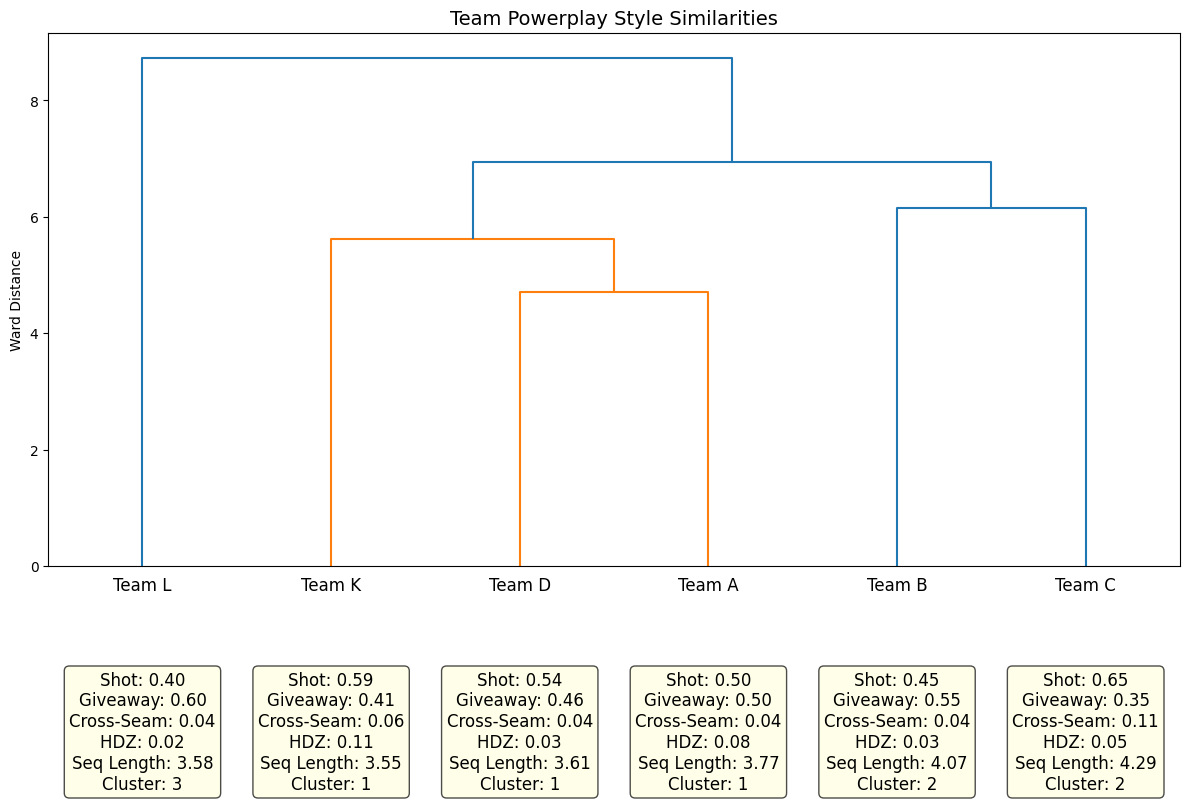

In [14]:
features = features_table_filtered.drop(columns = ['teams'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Z = linkage(scaled_features, method = 'ward')
features_table_filtered['cluster'] = fcluster(Z, t = 3, criterion = 'maxclust')

fig, ax = plt.subplots(figsize = (12,8))
dendro = dendrogram(
    Z,
    labels = features_table_filtered['teams'].values,
    ax = ax,
    leaf_rotation = 0)

ax.set_title('Team Powerplay Style Similarities', fontsize = 14)
ax.set_ylabel('Ward Distance')

team_order = dendro['ivl']
x_ticks = ax.get_xticks()

for i, team in enumerate(team_order):
  stats = team_features_table[team]
  cluster = features_table_filtered[features_table_filtered['teams'] == team]['cluster'].values[0]

  annotation = (
      f"Shot: {stats['shot']:.2f}\n"
      f"Giveaway: {stats['giveaway']:.2f}\n"
      f"Cross-Seam: {stats['cross_seam_prob']:.2f}\n"
      f"HDZ: {stats['high_danger_zone']:.2f}\n"
      f"Seq Length: {stats['expected_sequence_length']:.2f}\n"
      f"Cluster: {cluster}"
  )
  ax.annotate(
      annotation,
      xy = (x_ticks[i], 0),
      xytext = (x_ticks[i], -1.8),
      ha = 'center',
      va = 'top',
      fontsize = 12,
      annotation_clip = False,
      bbox = dict(boxstyle='round,pad=0.3', facecolor ='lightyellow', alpha = 0.7)
  )

plt.subplots_adjust(bottom=0.3)
plt.tight_layout()
plt.show()

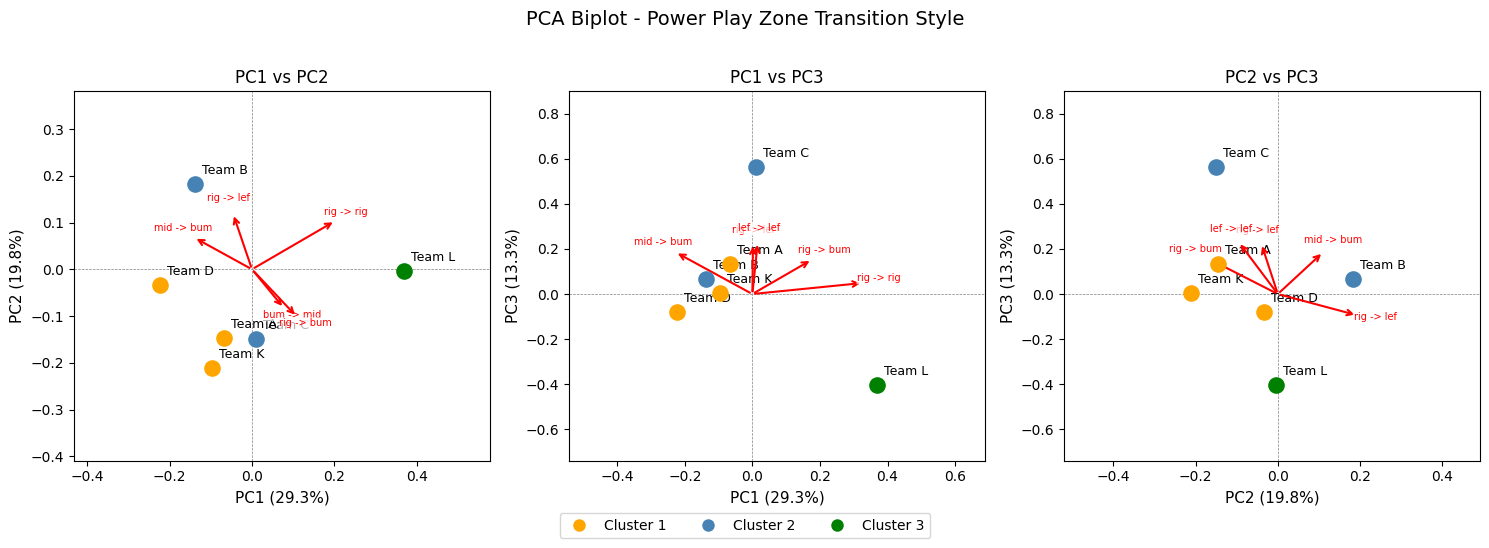

In [15]:
# Mapping from team to their index in zone_trans_pca
plot_valid_teams = ['Team A', 'Team B', 'Team C', 'Team D', 'Team L', 'Team K']
pairs = [(0, 1), (0, 2), (1, 2)]
pair_labels = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]

zone_names = ['left_point', 'right_point', 'middle_point', 'left_flank',
              'right_flank', 'bumper', 'left_net', 'right_net']

feature_names = [f"{z1[:3]} -> {z2[:3]}"
                 for z1 in zone_names
                 for z2 in zone_names]

components = pca_zone.components_
explained = pca_zone.explained_variance_ratio_
team_scores = zone_trans_pca

cluster_colors = {1: 'orange', 2: 'steelblue', 3: 'green'}
colors = [cluster_colors[features_table_filtered[
    features_table_filtered['teams'] == t]['cluster'].values[0]]
          for t in plot_valid_teams]

team_to_idx = {team: i for i, team in enumerate(valid_teams)}

def get_top_loadings(components, feature_names, i, j, top_n=5):
    """
    Get indices of features with largest combined loading on components i and j
    """
    combined = np.sqrt(components[i]**2 + components[j]**2)
    top_idx = np.argsort(combined)[-top_n:]
    return top_idx

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (i, j), (x_label, y_label) in zip(axes, pairs, pair_labels):
    for k, team in enumerate(plot_valid_teams):
        team_idx = team_to_idx[team]
        x_score = team_scores[team_idx, i]
        y_score = team_scores[team_idx, j]
        ax.scatter(x_score, y_score, color=colors[k], s=120, zorder=5)
        ax.annotate(
            team, (x_score, y_score),
            fontsize=9, ha='left', va='bottom',
            xytext=(5, 5), textcoords='offset points',
            annotation_clip=False
        )

    # Scale arrows relative to data spread
    x_scores_panel = [team_scores[team_to_idx[t], i] for t in plot_valid_teams]
    y_scores_panel = [team_scores[team_to_idx[t], j] for t in plot_valid_teams]
    data_range = max(
        max(x_scores_panel) - min(x_scores_panel),
        max(y_scores_panel) - min(y_scores_panel)
    )
    scale = data_range * 0.6

    top_idx = get_top_loadings(components, feature_names, i, j, top_n=5)

    for feat_idx in top_idx:
        dx = components[i, feat_idx] * scale
        dy = components[j, feat_idx] * scale
        ax.annotate(
            '',
            xy=(dx, dy), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
        )
        length = np.sqrt(dx**2 + dy**2)
        offset = data_range * 0.05
        if length > 0:
            label_x = dx + offset * dx / length
            label_y = dy + offset * dy / length
        else:
            label_x, label_y = dx * 1.15, dy * 1.15

        ax.text(
            label_x, label_y,
            feature_names[feat_idx],
            fontsize=7, color='red', ha='center',
            clip_on=False,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                      alpha=0.7, edgecolor='none')
        )

    ax.autoscale_view()
    margin = data_range * 0.3
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_xlim(xlim[0] - margin, xlim[1] + margin)
    ax.set_ylim(ylim[0] - margin, ylim[1] + margin)

    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel(f"{x_label} ({explained[i]*100:.1f}%)", fontsize=11)
    ax.set_ylabel(f"{y_label} ({explained[j]*100:.1f}%)", fontsize=11)
    ax.set_title(f'{x_label} vs {y_label}', fontsize=12)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
           markersize=10, label=f'Cluster {k}')
    for k, c in cluster_colors.items()
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('PCA Biplot - Power Play Zone Transition Style', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [16]:
print("Explained variance per component:")
for i, ev in enumerate(pca_zone.explained_variance_ratio_):
  print(f"PC{i+1} : {ev*100:.1f}%")
print(f"Total (5 components): {pca_zone.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance per component:
PC1 : 29.3%
PC2 : 19.8%
PC3 : 13.3%
PC4 : 11.6%
PC5 : 10.2%
Total (5 components): 84.4%


In [17]:
features_table_filtered['cluster'] = fcluster(Z, t = 3, criterion = 'maxclust')
cluster_means = features_table_filtered.groupby('cluster').mean(numeric_only=True)
print(cluster_means[['left_point_prob', 'right_point_prob', 'high_danger_zone_prob', 'shot_prob', 'expected_sequence_length']].T)

cluster                          1         2         3
left_point_prob           0.171901  0.249864  0.042221
right_point_prob          0.089966  0.122307  0.044216
high_danger_zone_prob     0.074527  0.038259  0.018903
shot_prob                 0.544587  0.549748  0.400068
expected_sequence_length  3.641053  4.182255  3.584698


In [18]:
print(features_table_filtered[['teams', 'cluster', 'high_danger_zone_prob', 'expected_sequence_length']])

    teams  cluster  high_danger_zone_prob  expected_sequence_length
0  Team D        1               0.032815                  3.607222
1  Team A        1               0.081884                  3.767783
2  Team L        3               0.018903                  3.584698
4  Team B        2               0.027833                  4.073278
6  Team C        2               0.048686                  4.291232
9  Team K        1               0.108882                  3.548155


In [19]:
print(features_table_filtered.set_index('teams').T.to_string())
for team in valid_teams_filtered:
  print(f"\n{'='*40}")
  print(f"Team: {team} (Cluster {features_table_filtered[features_table_filtered['teams']==team]['cluster'].values[0]})")
  print(f"{'='*40}")
  for seq, prob in team_features_table[team]['top_sequences']:
    print(f" {'->'.join(seq)} : {prob:.4f}")

teams                       Team D    Team A    Team L    Team B    Team C    Team K
left_point_prob           0.196491  0.176861  0.042221  0.309443  0.190286  0.142350
right_point_prob          0.125881  0.067143  0.044216  0.132167  0.112446  0.076873
middle_point_prob         0.085418  0.108464  0.093892  0.069112  0.095617  0.062951
left_flank_prob           0.085400  0.077305  0.056637  0.055498  0.054223  0.052802
right_flank_prob          0.112414  0.124334  0.041678  0.127680  0.136724  0.121734
bumper_prob               0.167206  0.138822  0.133507  0.104076  0.131760  0.170159
left_net_prob             0.142568  0.143171  0.373286  0.088802  0.136726  0.156127
right_net_prob            0.084623  0.163900  0.214564  0.113222  0.142219  0.217005
high_danger_zone_prob     0.032815  0.081884  0.018903  0.027833  0.048686  0.108882
shot_prob                 0.544895  0.503152  0.400068  0.451347  0.648149  0.585716
giveaway_prob             0.455105  0.496848  0.599932  0.548653 

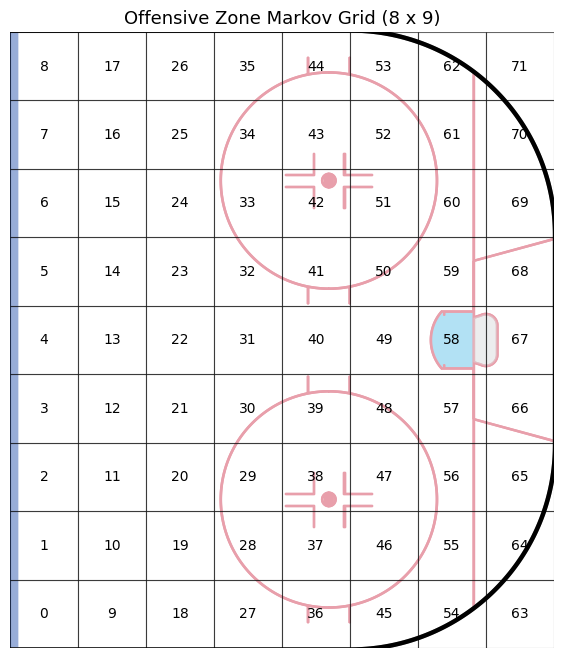

In [20]:
x_min = 25
x_max = 100
y_min = -42.5
y_max = 42.5

length = 8
width = 9

x_range = x_max - x_min
y_range = y_max - y_min

x_bin_size = x_range / length
y_bin_size = y_range / width

fig, ax = plt.subplots(figsize=(10, 8))


# NHL Rink with Markov Chain States
rink = NHLRink()
rink.draw(ax=ax)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

for state in range(nb_rink_states):
    x_idx = state // width
    y_idx = state % width
    x_left = x_min + x_idx * x_bin_size
    y_bottom = y_min + y_idx * y_bin_size

    rec = plt.Rectangle(
        (x_left, y_bottom),
        x_bin_size, y_bin_size,
        facecolor='white',
        alpha=0.6,
        edgecolor='black',
        linewidth=0.8,
        zorder=20
    )
    ax.add_patch(rec)
    ax.text(
        x_left + x_bin_size / 2,
        y_bottom + y_bin_size / 2,
        str(state),
        ha='center', va='center',
        fontsize=10, zorder=21, color='black'
    )

rink.draw(ax=ax)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("Offensive Zone Markov Grid (8 x 9)", fontsize=13)
ax.set_aspect('equal')

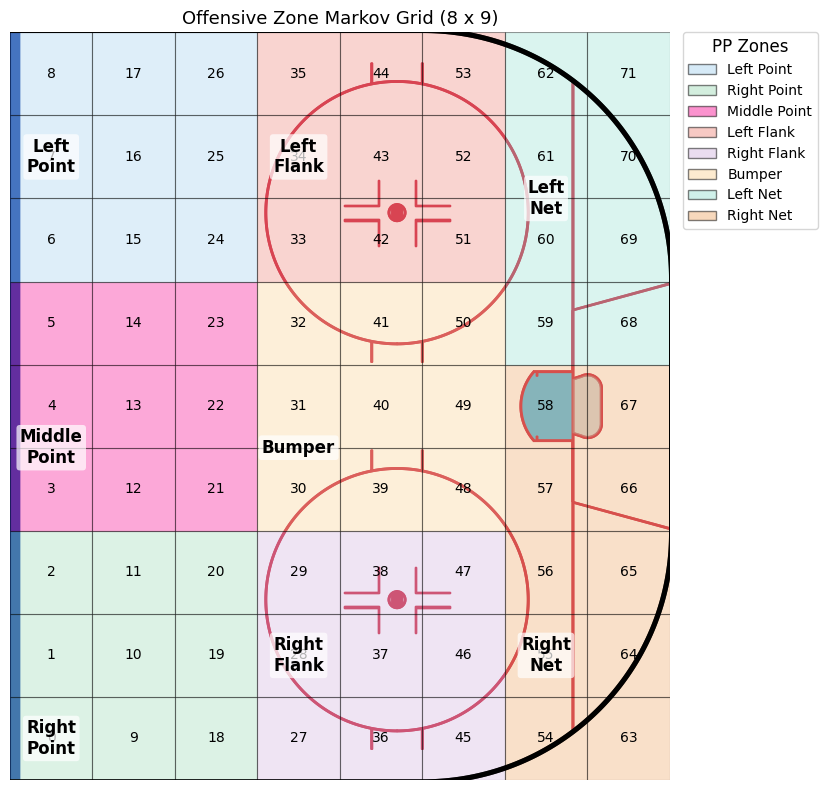

In [21]:
x_min = 25
x_max = 100
y_min = -42.5
y_max = 42.5

length = 8
width = 9

x_range = x_max - x_min
y_range = y_max - y_min

x_bin_size = x_range / length
y_bin_size = y_range / width


# Zone Colors
zone_colors = {
    'left_point' : '#AED6F1',
    'right_point' : '#A9DFBF',
    'middle_point' : '#F9279F',
    'left_flank' : '#F1948A',
    'right_flank' : '#D7BDE2',
    'bumper' : '#FAD7A0',
    'left_net' : '#A3E4D7',
    'right_net' : '#F0B27A',
}

state_to_zone = {}

for zone, states in pp_zones.items():
  for s in states:
    if zone == 'high_danger_zone':
      state_to_zone[s] = zone
    elif s not in state_to_zone:
      state_to_zone[s] = zone

# Drawing NHL Rink
fig, ax = plt.subplots(figsize=(10, 8))

rink = NHLRink()
rink.draw(ax=ax)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Adding Color power play zones

for state in range(nb_rink_states):
    x_idx = state // width
    y_idx = state % width

    x_left = x_min + x_idx * x_bin_size
    y_bottom = y_min + y_idx * y_bin_size

    zone = state_to_zone.get(state, None)
    color = zone_colors.get(zone, 'white')

    rec = plt.Rectangle(
         (x_left, y_bottom),
         x_bin_size,
         y_bin_size,
         facecolor = color,
         alpha = 0.4,
         edgecolor = 'black',
         linewidth = 0.8,
         zorder = 20
     )


    ax.add_patch(rec)
    ax.text(
        x_left + x_bin_size / 2,
        y_bottom + y_bin_size / 2,
        str(state),
        ha = 'center',
        va = 'center',
        fontsize = 10,
        zorder = 20,
        color = 'black'
        )

zone_label_positions = {
    'left_point' : (x_min + 0.5 * x_bin_size, y_min + 7.5 * y_bin_size),
    'right_point' : (x_min + 0.5 * x_bin_size, y_min + 0.5 * y_bin_size),
    'middle_point' : (x_min + 0.5 * x_bin_size, y_min + 4.0 * y_bin_size),
    'left_flank' : (x_min + 3.5 * x_bin_size, y_min + 7.5 * y_bin_size),
    'right_flank' : (x_min + 3.5 * x_bin_size, y_min + 1.5 * y_bin_size),
    'bumper' : (x_min + 3.5 * x_bin_size, y_min + 4.0 * y_bin_size),
    'left_net' : (x_min + 6.5 * x_bin_size, y_min + 7.0 * y_bin_size),
    'right_net' : (x_min + 6.5 * x_bin_size, y_min + 1.5 * y_bin_size)
}

zone_display_names = {
    'left_point' : 'Left\nPoint',
    'right_point' : 'Right\nPoint',
    'middle_point' : 'Middle\nPoint',
    'left_flank' : 'Left\nFlank',
    'right_flank' : 'Right\nFlank',
    'bumper' : 'Bumper',
    'left_net' : 'Left\nNet',
    'right_net' : 'Right\nNet'
}

for zone, (x_pos, y_pos) in zone_label_positions.items():
    ax.text(
        x_pos, y_pos,
        zone_display_names[zone],
        ha = 'center',
        va = 'center',
        fontsize = 12,
        fontweight = 'bold',
        color = 'black',
        zorder = 25,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
    )

legend_elements = [
    Patch(facecolor=zone_colors[zone], alpha=0.5, edgecolor='black', label=zone_display_names[zone].replace('\n', ' '))
    for zone in zone_colors
]

ax.legend(
    handles=legend_elements,
    loc = 'upper left',
    bbox_to_anchor = (1.02, 1),
    fontsize = 10,
    title = 'PP Zones',
    title_fontsize = 12,
    framealpha = 0.8,
    borderaxespad = 0
)

rink.draw(ax=ax)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_title("Offensive Zone Markov Grid (8 x 9)", fontsize=13)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

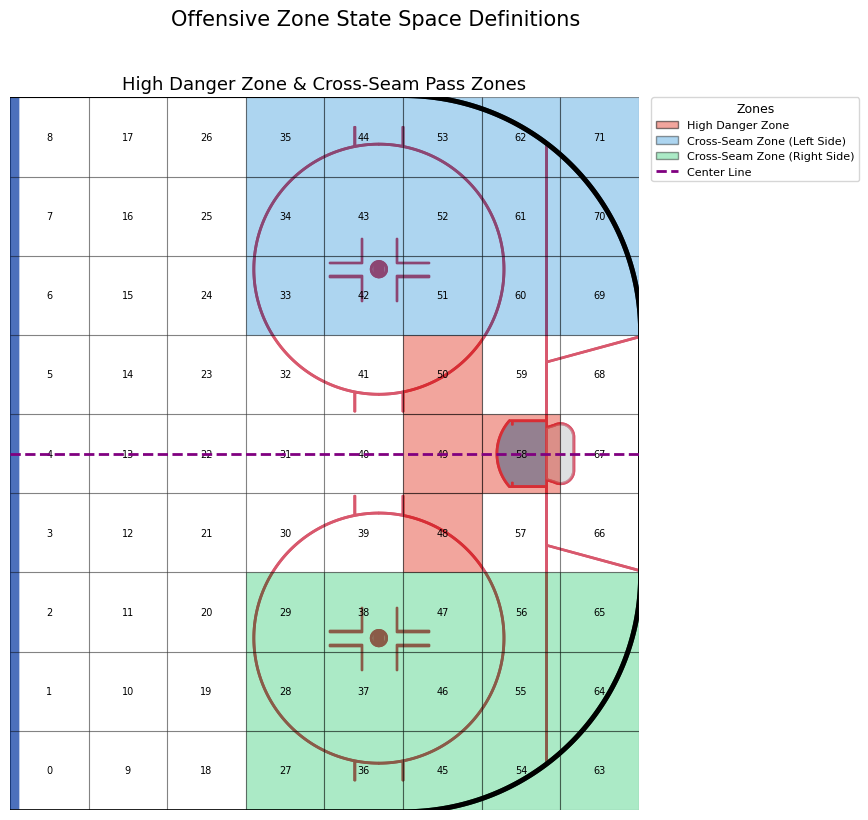

In [22]:
x_min = 25
x_max = 100
y_min = -42.5
y_max = 42.5

length = 8
width = 9

x_range = x_max - x_min
y_range = y_max - y_min

x_bin_size = x_range / length
y_bin_size = y_range / width

fig, ax = plt.subplots(figsize=(10, 8))

# NHL Rink no power play zones
rink = NHLRink()
rink.draw(ax=ax)

# High danger zone states
hdz_states = {48, 49, 50, 58}

# Cross-seam source zones: y_idx <= 2 (right side) and y_idx >= 6 (left side)
# is_deep: x_idx >= 3
cross_seam_source_left = set()
cross_seam_source_right = set()
cross_seam_target = set()
for state in range(nb_rink_states):
    x_idx = state // width
    y_idx = state % width
    if y_idx >= 6:
        cross_seam_source_left.add(state)
    if y_idx <= 2:
        cross_seam_source_right.add(state)
    if x_idx >= 3:
        cross_seam_target.add(state)

cross_seam_left_target = cross_seam_source_left & cross_seam_target
cross_seam_right_target = cross_seam_source_right & cross_seam_target

for state in range(nb_rink_states):
    x_idx = state // width
    y_idx = state % width
    x_left = x_min + x_idx * x_bin_size
    y_bottom = y_min + y_idx * y_bin_size

    if state in hdz_states:
        color = '#E74C3C'
        alpha = 0.5
    elif state in cross_seam_left_target:
        color = '#3498DB'
        alpha = 0.4
    elif state in cross_seam_right_target:
        color = '#2ECC71'
        alpha = 0.4
    else:
        color = 'white'
        alpha = 0.3

    rec = plt.Rectangle(
        (x_left, y_bottom),
        x_bin_size, y_bin_size,
        facecolor=color,
        alpha=alpha,
        edgecolor='black',
        linewidth=0.8,
        zorder=20
    )
    ax.add_patch(rec)
    ax.text(
        x_left + x_bin_size / 2,
        y_bottom + y_bin_size / 2,
        str(state),
        ha='center', va='center',
        fontsize=7, zorder=21, color='black'
    )


# Center Line (net to top of faceoff circle)
# y=0 is center of ice, draw vertical line from net (x=100) to top faceoff circle (~x=69)
ax.plot(
    [x_min, x_max],
    [0, 0],
    color='purple',
    linewidth=2,
    linestyle='--',
    zorder=25,
    label='Center Line'
)

rink.draw(ax=ax)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.5, edgecolor='black', label='High Danger Zone'),
    Patch(facecolor='#3498DB', alpha=0.4, edgecolor='black', label='Cross-Seam Zone (Left Side)'),
    Patch(facecolor='#2ECC71', alpha=0.4, edgecolor='black', label='Cross-Seam Zone (Right Side)'),
    Line2D([0], [0], color='purple', linewidth=2, linestyle='--', label='Center Line')
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=8,
    title='Zones',
    title_fontsize=9,
    framealpha=0.8,
    borderaxespad=0
)

ax.set_title("High Danger Zone & Cross-Seam Pass Zones", fontsize=13)
ax.set_aspect('equal')

plt.suptitle("Offensive Zone State Space Definitions", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
def get_expected_visits_heatmap(dtmc, nb_rink_states):
  """
  Computes the normalised expected puck visitation frequency for each rink state.

  Uses the initial distribution and fundamental matrix of a discrete-time Markov
  chain (DTMC) to calculate the expected number of visits to each transient state
  before absorption, weighted by the probability of starting in each state.
  The result is normalised to sum to 1, giving a probability distribution over
  rink states that can be used to construct a puck movement heatmap.
  """
  init = dtmc.initial_distribution[:nb_rink_states]
  fundamental = dtmc.fundamental_matrix
  expected_visits = init @ fundamental
  expected_visits = expected_visits / expected_visits.sum()

  return expected_visits

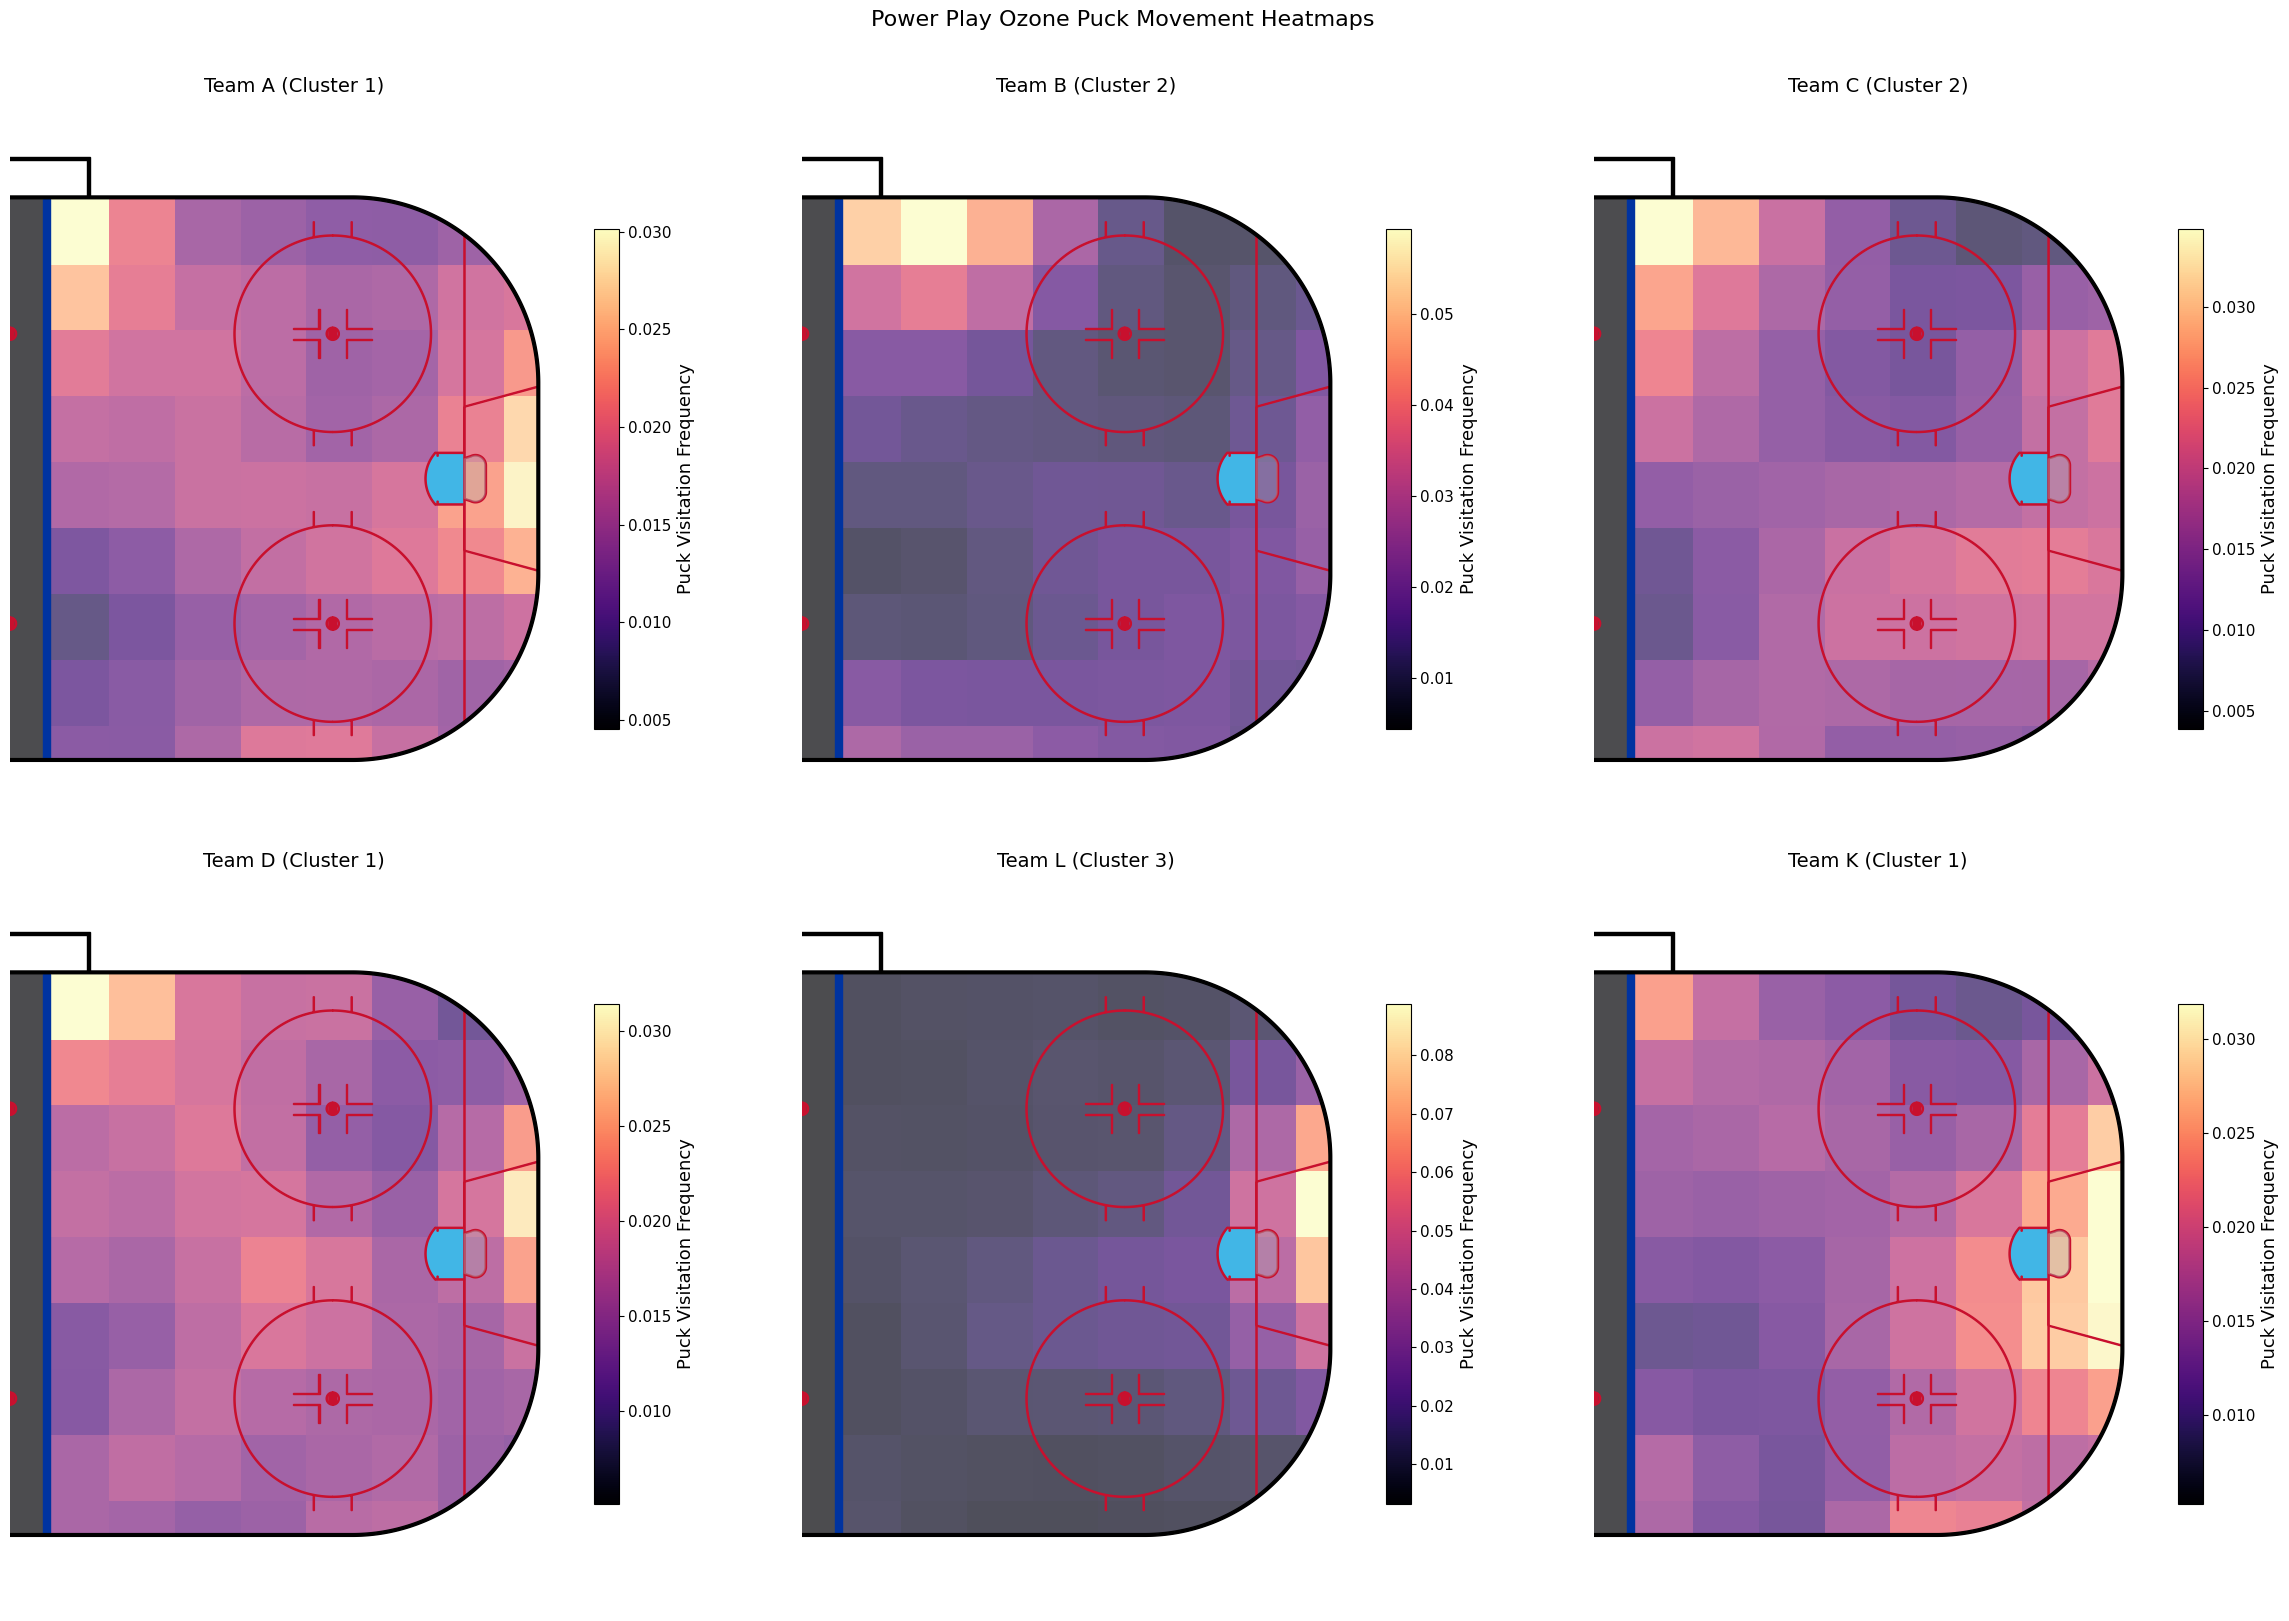

In [24]:
plot_valid_teams = ['Team A', 'Team B', 'Team C', 'Team D', 'Team L', 'Team K']

def plot_all_team_heatmaps(plot_valid_teams, team_features_table, features_table_filtered,
                            length=8, width=9, x_max=75, y_max=85):
    """
    Plots a 2x3 grid of puck movement heatmaps for all valid power play teams.

    For each team, computes the normalised expected puck visitation frequency
    using the team-specific DTMC fundamental matrix and initial distribution,
    applies Gaussian smoothing, and overlays the result as a heatmap on an
    NHL offensive zone rink diagram. Each subplot displays the team name and
    cluster assignment in the title.
    """

    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    axes = axes.flatten()

    x_bin = x_max / length
    y_bin = y_max / width

    for idx, team in enumerate(plot_valid_teams):
        ax = axes[idx]

        heatmap_vec = get_expected_visits_heatmap(
            team_features_table[team]['dtmc'],
            nb_rink_states=nb_rink_states
        )

        grid = heatmap_vec.reshape(length, width)
        grid_smooth = gaussian_filter(grid, sigma=1.0)

        x_coords = []
        y_coords = []
        values = []

        for x_idx in range(length):
            for y_idx in range(width):
                value = float(grid_smooth[x_idx, y_idx])
                if value <= 0:
                    continue
                x_center = x_idx * x_bin + x_bin / 2
                y_center = y_idx * y_bin + y_bin / 2
                x_coords.append(float(x_center + 25))
                y_coords.append(float(y_center - 42.5))
                values.append(value)

        cluster = features_table_filtered[
            features_table_filtered['teams'] == team
        ]['cluster'].values[0]

        rink = NHLRink()
        rink.draw(ax=ax, display_range='ozone')

        rink.heatmap(
            x=x_coords,
            y=y_coords,
            values=values,
            statistic='sum',
            cmap='magma',
            binsize=10,
            ax=ax,
            alpha=0.7,
            zorder=11
        )

        sm = plt.cm.ScalarMappable(
            cmap='magma',
            norm=plt.Normalize(vmin=min(values), vmax=max(values))
        )
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
        cbar.set_label('Puck Visitation Frequency', fontsize=13)
        cbar.ax.tick_params(labelsize=11)

        team_stats = team_features_table[team]
        ax.set_title(
            f"{team} (Cluster {cluster})\n",
            fontsize=14
        )

    plt.suptitle('Power Play Ozone Puck Movement Heatmaps', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_all_team_heatmaps(
    plot_valid_teams, team_features_table, features_table_filtered
)


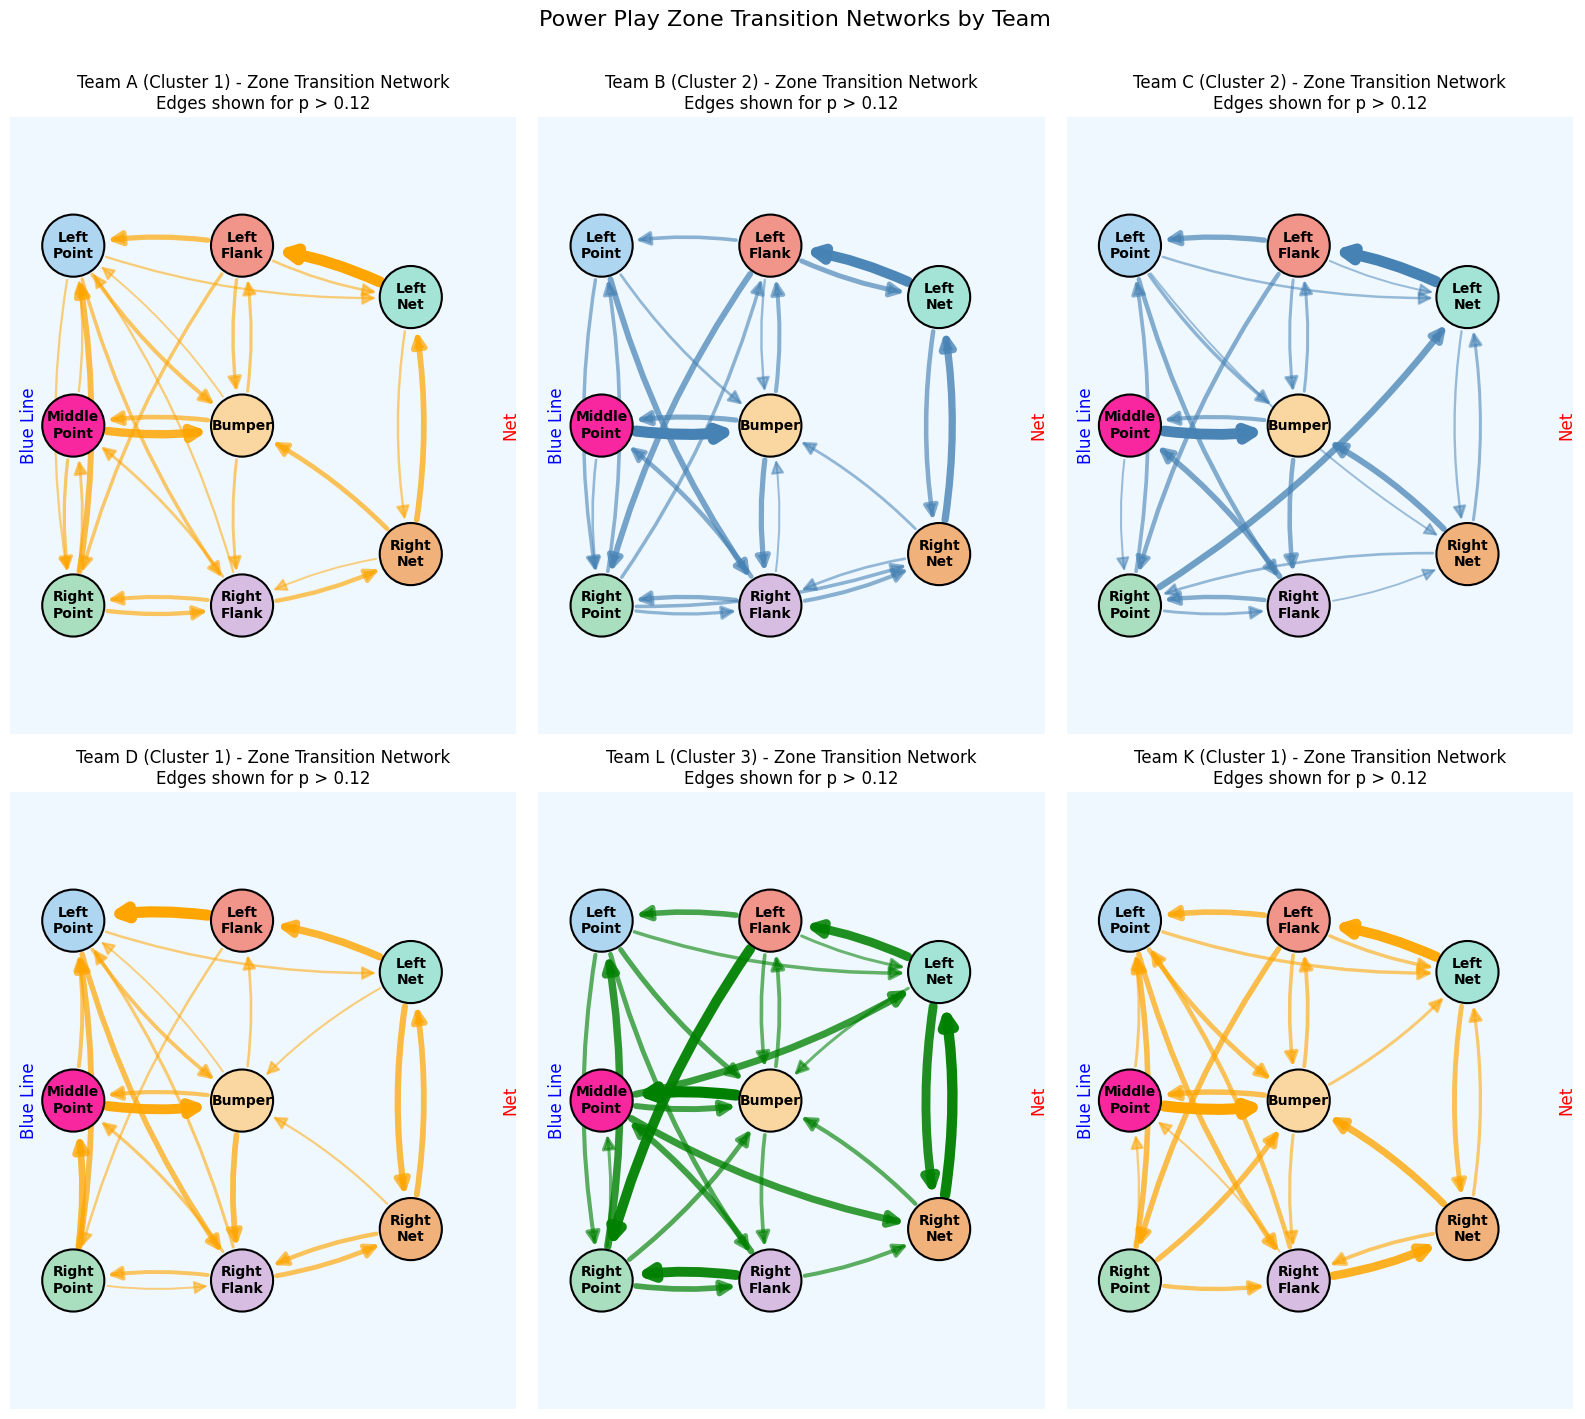

In [25]:
zone_names = ['left_point', 'right_point', 'middle_point', 'left_flank', 'right_flank', 'bumper',
              'left_net', 'right_net']


zone_display_names = {
    'left_point' : 'Left\nPoint',
    'right_point' : 'Right\nPoint',
    'middle_point' : 'Middle\nPoint',
    'left_flank' : 'Left\nFlank',
    'right_flank' : 'Right\nFlank',
    'bumper' : 'Bumper',
    'left_net' : 'Left\nNet',
    'right_net' : 'Right\nNet'
}

node_positions = {
    'left_point' : (0.05, 0.85),
    'right_point' : (0.05, 0.15),
    'middle_point' : (0.05, 0.5),
    'left_flank'  : (0.45, 0.85),
    'right_flank' :  (0.45, 0.15),
    'bumper'  : (0.45, 0.5),
    'left_net'  : (0.85, 0.75),
    'right_net' : (0.85, 0.25)
}

cluster_colors = {1 : 'orange', 2 : 'steelblue', 3 : 'green'}

fig, axes = plt.subplots(2, 3, figsize = (16,14))
axes = axes.flatten()

for idx, team in enumerate(plot_valid_teams):
  ax = axes[idx]

  zone_trans = team_features_table[team]['zone_trans_flat'].reshape(8,8)

  cluster = features_table_filtered[
      features_table_filtered['teams'] == team
  ]['cluster'].values[0]

  G = nx.DiGraph()
  G.add_nodes_from(zone_names)

  threshold = 0.12
  edges = []
  weights = []

  for i, from_zone in enumerate(zone_names):
    for j, to_zone in enumerate(zone_names):
      prob = zone_trans[i,j]
      if prob > threshold:
        G.add_edge(from_zone, to_zone, weight=prob)
        edges.append((from_zone, to_zone))
        weights.append(prob)

  max_weight = max(weights) if weights else 1
  edge_widths = [8 * (w / max_weight) for w in weights]
  edge_alphas = [0.4 + 0.6 * (w / max_weight) for w in weights]

  node_sizes = [
    max(2000, 5000 * team_features_table[team].get(zone, 0.05))
    for zone in zone_names
]

  zone_colors = {
    'left_point' : '#AED6F1',
    'right_point' : '#A9DFBF',
    'middle_point' : '#F9279F',
    'left_flank' : '#F1948A',
    'right_flank' : '#D7BDE2',
    'bumper' : '#FAD7A0',
    'left_net' : '#A3E4D7',
    'right_net' : '#F0B27A'
    }

  node_colors = [zone_colors[z] for z in zone_names]

  nx.draw_networkx_nodes(
      G, node_positions, ax = ax,
      node_color = node_colors,
      node_size = node_sizes,
      edgecolors = 'black',
      linewidths = 1.5
      )

  nx.draw_networkx_labels(
      G, node_positions, ax=ax,
      labels=zone_display_names,
      font_size=10,
      font_color = 'black',
      font_weight='bold'
      )

  for edge, width, alpha in zip(edges, edge_widths, edge_alphas):
      nx.draw_networkx_edges(
          G, node_positions, ax=ax,
          edgelist=[edge],
          width=width,
          alpha=alpha,
          edge_color=cluster_colors[cluster],
          arrows=True,
          arrowsize=20,
          connectionstyle='arc3,rad=0.1',
          min_source_margin=25,
          min_target_margin = 25
          )

  ax.set_title(
      f"{team} (Cluster {cluster}) - Zone Transition Network\n"
      f"Edges shown for p > {threshold}",
      fontsize = 12
  )

  rink_bg = FancyBboxPatch((0.0, 0.0), 1.0, 1.0,
                           boxstyle='round,pad=0.05',
                           facecolor='#f0f8ff',
                           linewidth=2, transform=ax.transAxes,zorder=0)
  ax.add_patch(rink_bg)

  ax.set_xlim(-0.1, 1.1)
  ax.set_ylim(-0.1, 1.1)
  ax.axis('off')

  ax.text(0.02, 0.5, 'Blue Line', fontsize=12, color='blue',
          transform=ax.transAxes, va='center', rotation=90)
  ax.text(0.97, 0.5, 'Net', fontsize=12, color='red',
          transform=ax.transAxes, va='center', rotation=90)

plt.suptitle('Power Play Zone Transition Networks by Team', fontsize = 16, y = 1.01)
plt.tight_layout()
plt.show()


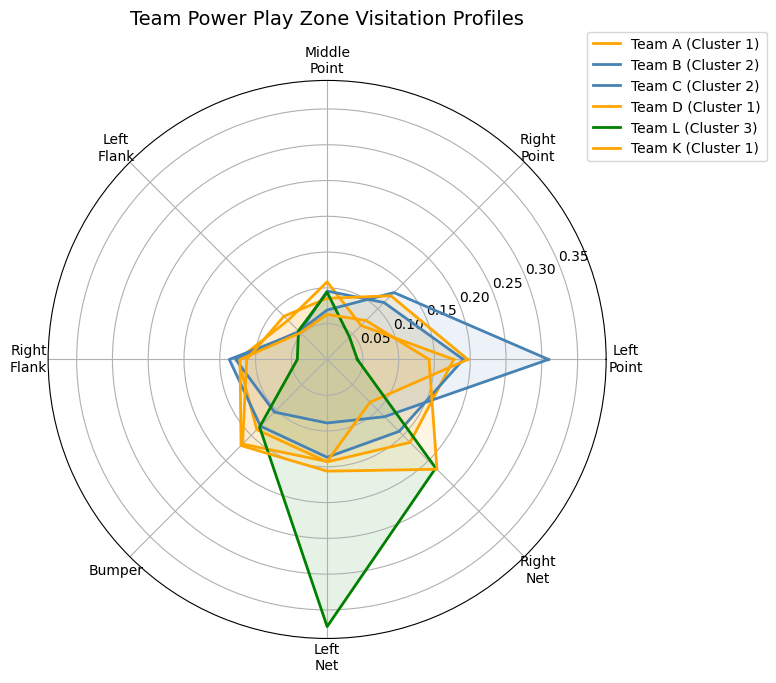

In [26]:
zones = ['left_point', 'right_point', 'middle_point', 'left_flank', 'right_flank', 'bumper',
         'left_net', 'right_net']

zone_display = ['Left\nPoint', 'Right\nPoint', 'Middle\nPoint', 'Left\nFlank', 'Right\nFlank', 'Bumper',
         'Left\nNet', 'Right\nNet']

team_data = {
    team : [team_features_table[team][zone] for zone in zones]
    for team in plot_valid_teams
    }

cluster_colors = {1 : 'orange', 2 : 'steelblue', 3 : 'green'}

N = len(zones)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for team in plot_valid_teams:
  values = team_data[team][:]
  values += values[:1]

  cluster = features_table_filtered[
      features_table_filtered['teams'] == team
  ]['cluster'].values[0]

  color = cluster_colors[cluster]

  ax.plot(angles, values, color=color, linewidth=2, label = f"{team} (Cluster {cluster})")
  ax.fill(angles, values, color=color,alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(zone_display, fontsize=10)
ax.set_title('Team Power Play Zone Visitation Profiles', fontsize=14, pad=40)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


In [27]:
for team in plot_valid_teams:
  print(f"\n{team}:")
  print(f" shot: {team_features_table[team]['shot']:.6f}")
  print(f" giveaway: {team_features_table[team]['giveaway']:.6f}")

  team_df = ppp_ozone_df[ppp_ozone_df['Team_Events'] == team]
  absorbing_transitions = team_df[team_df['NextState'].isin(absorbing_states)]
  print(f" absorbing transitions: {len(absorbing_transitions)}")
  print(f" nextstate value counts : {absorbing_transitions['NextState'].value_counts()}")


Team A:
 shot: 0.503152
 giveaway: 0.496848
 absorbing transitions: 8
 nextstate value counts : NextState
72.0    5
73.0    3
Name: count, dtype: int64

Team B:
 shot: 0.451347
 giveaway: 0.548653
 absorbing transitions: 6
 nextstate value counts : NextState
73.0    3
72.0    3
Name: count, dtype: int64

Team C:
 shot: 0.648149
 giveaway: 0.351851
 absorbing transitions: 6
 nextstate value counts : NextState
72.0    3
73.0    3
Name: count, dtype: int64

Team D:
 shot: 0.544895
 giveaway: 0.455105
 absorbing transitions: 7
 nextstate value counts : NextState
73.0    4
72.0    3
Name: count, dtype: int64

Team L:
 shot: 0.400068
 giveaway: 0.599932
 absorbing transitions: 8
 nextstate value counts : NextState
73.0    4
72.0    4
Name: count, dtype: int64

Team K:
 shot: 0.585716
 giveaway: 0.414284
 absorbing transitions: 9
 nextstate value counts : NextState
73.0    6
72.0    3
Name: count, dtype: int64


In [28]:
print(f"absorbing_states: {absorbing_states}")
print(f"giveaway_states : {giveaway_state}")
print(f"shot_states : {shot_state}")

print("\nAll NextState values near absorbing range:")
print(ppp_ozone_df[ppp_ozone_df['NextState'] >= 72]['NextState'].value_counts())

absorbing_states: (72, 73)
giveaway_states : 72
shot_states : 73

All NextState values near absorbing range:
NextState
73.0    32
72.0    29
Name: count, dtype: int64
